# 🏥 Healthcare Analytics — EDA Project

**Tools:** Python • Pandas • NumPy • Matplotlib • Seaborn  
**Dataset:** Synthetic healthcare analytics dataset with intentionally injected data-quality issues  
**Objective:** Clean the dirty source data, validate relationships, explore patterns, answer business questions, and create analysis-ready outputs.

# About the Dataset

## Major Hospital Analytics Project

This project is based on a large-scale **Hospital dataset** created for practicing real-world data analysis using Python, Pandas, Matplotlib, and Seaborn.

The dataset contains multiple interconnected tables representing different parts of a hospital, including departments, doctors, patients, appointments, admissions, billing, and lab tests.

The main objective of this project is to simulate a real-world healthcare analytics environment where raw and imperfect data must be cleaned, transformed, combined, analyzed, and converted into meaningful business insights.

## Dataset Structure

The project contains seven relational tables:

* **Departments** – Department names, floors, bed capacity and head doctor.
* **Doctors** – Doctor details, department, experience, consultation fee and joining date.
* **Patients** – Patient demographics, city, blood group, insurance type and registration date.
* **Appointments** – OPD visits with patient, doctor, type, status, wait time and satisfaction score.
* **Admissions** – Hospital stays with diagnosis, admission/discharge dates, room type and outcome.
* **Billing** – Bill amount, insurance coverage, payment method and payment status for each admission.
* **Lab Tests** – Test name, result value, unit, cost and result flag for each admission.

## Relationships Between Tables

The tables are connected through primary and foreign keys.

```text
Departments
    │
    │ department_id
    ↓
Doctors ─────────────────────────────┐
    │                                │
    │ doctor_id                      │ department_id
    ↓                                ↓
Appointments ←── patient_id ── Patients ── patient_id ──→ Admissions ←── doctor_id ── Doctors
                                                               │
                                                               ├──────────────→ Billing   (admission_id)
                                                               │
                                                               └──────────────→ Lab Tests (admission_id)
```

## Skills Practiced

* Data Cleaning (nulls, duplicates, wrong data types, inconsistent text, impossible values)
* Data Integration (merging many tables)
* Feature Engineering
* Univariate, Bivariate and Time-based EDA
* Business Question Solving

#### Author - Sahil Kanojia

#### (Data science aspirant)

## Import Libraries


#### We will use the following libraries

1. Pandas: Data manipulation and analysis

2. Numpy: Numerical operations and calculations

3. Matplotlib: Data visualization and plotting

4. Seaborn: Enhanced data visualization and statistical graphics

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Exploration | Cleaning

#### Loading the csv file



In [183]:
df_department = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\departments.csv")
df_doctor = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\doctors.csv")
df_patient = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\patients.csv")
df_appointment = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\appointments.csv")
df_admission = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\admissions.csv")
df_billing = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\billing.csv")
df_lab = pd.read_csv("C:\\Users\\sagar\\Downloads\\hospital_data\\lab_tests.csv")

#### Set option to see max columns

In [184]:
pd.set_option('display.max_columns', None)

### A helper function for dates

Many date columns are stored in **mixed formats** (like `2024-03-05`, `05/03/2024`, `03-05-24`, `05 Mar 2024`).
`pd.to_datetime()` alone cannot read them correctly, so this small function tries each format one by one.

In [185]:
def parse_mixed_date(col):
    col = col.astype("string").str.strip()
    out = pd.to_datetime(col, format="%Y-%m-%d", errors="coerce")
    for fmt in ("%d/%m/%Y", "%m-%d-%y", "%d %b %Y"):
        out = out.fillna(pd.to_datetime(col, format=fmt, errors="coerce"))
    return out

# EXPLORING DEPARTMENT TABLE!

The purpose of a exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [186]:
df_department.head()

,department_id,department_name,floor,bed_capacity,head_doctor_id
0,1,Cardiology,7,33,219
1,2,Neurology,4,12,59
2,3,Orthopedics,5,31,170
3,4,Pediatrics,7,62,220
4,5,Oncology,3,11,188


### Lets see the shape and columns name

In [187]:
print(df_department.shape)
df_department.columns

(15, 5)


Index(['department_id', 'department_name', 'floor', 'bed_capacity',
       'head_doctor_id'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [188]:
df_department.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   department_id    15 non-null     int64 
 1   department_name  15 non-null     object
 2   floor            15 non-null     int64 
 3   bed_capacity     15 non-null     int64 
 4   head_doctor_id   15 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 732.0+ bytes


### check for null value

In [189]:
df_department.isna().sum()

department_id      0
department_name    0
floor              0
bed_capacity       0
head_doctor_id     0
dtype: int64

### Check for duplicate row

In [190]:
df_department.duplicated().sum()

np.int64(0)

### Check for data consistancy

In [191]:
for i in (df_department.columns):
    print(i)
    print(df_department[i].unique())
    print(df_department[i].nunique())
    print()
    print("-"* 70)

department_id
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
15

----------------------------------------------------------------------
department_name
['Cardiology' 'Neurology' 'Orthopedics' 'Pediatrics' 'Oncology'
 'Emergency' 'Gynecology' 'Dermatology' 'Psychiatry' 'Radiology' 'ENT'
 'Urology' 'Gastroenterology' 'Nephrology' 'General Medicine']
15

----------------------------------------------------------------------
floor
[7 4 5 3 2]
5

----------------------------------------------------------------------
bed_capacity
[33 12 31 62 11 39 47 73 69 30 42 67 58]
13

----------------------------------------------------------------------
head_doctor_id
[219  59 170 220 188 208  15 190 175  51 108  55 244]
13

----------------------------------------------------------------------


# OBSERVATIONS :
#### 1 -> There are 15 rows and 5 columns in this table

#### 2 -> Columns are 'department_id', 'department_name', 'floor', 'bed_capacity', 'head_doctor_id'

#### 3 -> No null values, no duplicate rows and all data types are proper

#### 4 -> This is a small lookup table, so no cleaning is required

### ------------------------------------------------------------------------------------------

### MOVING TO THE NEXT TABLE!

### ------------------------------------------------------------------------------------------

## EXPLORING DOCTOR TABLE!

The purpose of exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [192]:
df_doctor.head()

,doctor_id,doctor_name,department_id,specialization,experience_years,consultation_fee,joining_date
0,1,Dr. Sneha Sharma,9,Specialist,33,800.0,2021-11-01
1,2,Dr. Arjun Singh,3,Resident,10,800.0,2012-12-08
2,3,Dr. Neha Gupta,5,Consultant,29,500.0,2005-03-19
3,4,Dr. Sneha Nair,3,NaN,13,1000.0,2012-03-06
4,5,Dr. Isha Verma,7,Senior Consultant,12,300.0,2016-07-29


### Lets see the shape and columns name

In [193]:
print(df_doctor.shape)
df_doctor.columns

(250, 7)


Index(['doctor_id', 'doctor_name', 'department_id', 'specialization',
       'experience_years', 'consultation_fee', 'joining_date'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [194]:
df_doctor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   doctor_id         250 non-null    int64  
 1   doctor_name       250 non-null    object 
 2   department_id     250 non-null    int64  
 3   specialization    229 non-null    object 
 4   experience_years  250 non-null    int64  
 5   consultation_fee  240 non-null    float64
 6   joining_date      250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


### check for null value

In [195]:
df_doctor.isna().sum()

doctor_id            0
doctor_name          0
department_id        0
specialization      21
experience_years     0
consultation_fee    10
joining_date         0
dtype: int64

### Check for duplicate row

In [196]:
df_doctor.duplicated().sum()

np.int64(0)

In [197]:
df_doctor.describe()

,doctor_id,department_id,experience_years,consultation_fee
count,250.000000,250.000000,250.000000,240.000000
mean,125.500000,8.116000,21.880000,1039.166667
std,72.312977,4.373908,16.134276,601.434246
min,1.000000,1.000000,-3.000000,300.000000
25%,63.250000,4.000000,11.000000,500.000000
50%,125.500000,8.000000,21.000000,800.000000
75%,187.750000,12.000000,31.000000,1500.000000
max,250.000000,15.000000,150.000000,2000.000000


### Check for data consistancy

In [198]:
for i in (df_doctor.columns):
    print(i)
    print(df_doctor[i].unique())
    print(df_doctor[i].nunique())
    print()
    print("-"* 70)

doctor_id
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 

## OBSERVATIONS :
#### 1 -> There are 250 rows and 7 columns in this table

#### 2 -> Null values are present in: specialization (21), consultation_fee (10)

#### 3 -> joining_date is in object form and has mixed date formats

#### 4 -> experience_years has 5 impossible values (negative or above 60 years)

#### 5 -> There are no duplicate rows

## CLEANING DOCTOR TABLE DATA

#### 1 - Changing Data Types of Columns in required form

In [199]:
df_doctor["joining_date"] = parse_mixed_date(df_doctor["joining_date"])
df_doctor.dtypes

doctor_id                    int64
doctor_name                 object
department_id                int64
specialization              object
experience_years             int64
consultation_fee           float64
joining_date        datetime64[ns]
dtype: object

#### 2 - Deal with impossible values

Experience cannot be negative and a doctor cannot have more than 60 years of experience, so we mark these as null and fill them along with other nulls.

In [200]:
df_doctor[(df_doctor["experience_years"] < 0) | (df_doctor["experience_years"] > 60)]

,doctor_id,doctor_name,department_id,specialization,experience_years,consultation_fee,joining_date
37,38,Dr. Arjun Khan,6,Consultant,-3,300.0,2020-10-14
51,52,Dr. Sanjay Iyer,14,Surgeon,-1,NaN,2011-01-14
76,77,Dr. Sneha Nair,13,Surgeon,120,300.0,2013-11-03
203,204,Dr. Isha Patel,8,Specialist,99,800.0,2020-01-02
229,230,Dr. Priya Patel,12,Specialist,150,500.0,2023-03-13


In [201]:
df_doctor.loc[(df_doctor["experience_years"] < 0) | (df_doctor["experience_years"] > 60), "experience_years"] = np.nan

#### 3 - Deal with null value

In [202]:
df_doctor.isna().sum() * 100 / len(df_doctor)

doctor_id           0.0
doctor_name         0.0
department_id       0.0
specialization      8.4
experience_years    2.0
consultation_fee    4.0
joining_date        0.0
dtype: float64

##### Fill the null values as

##### specialization -> Mode
##### consultation_fee -> Median (fee has fixed slabs, so median is safer than mean)
##### experience_years -> Median

In [203]:
df_doctor["specialization"] = df_doctor["specialization"].fillna(df_doctor["specialization"].mode()[0])
df_doctor["consultation_fee"] = df_doctor["consultation_fee"].fillna(df_doctor["consultation_fee"].median())
df_doctor["experience_years"] = df_doctor["experience_years"].fillna(df_doctor["experience_years"].median())
df_doctor["consultation_fee"] = df_doctor["consultation_fee"].astype("int64")
df_doctor["experience_years"] = df_doctor["experience_years"].astype("int64")

#### Check

In [204]:
df_doctor.isnull().sum()

doctor_id           0
doctor_name         0
department_id       0
specialization      0
experience_years    0
consultation_fee    0
joining_date        0
dtype: int64

In [205]:
df_doctor.duplicated().sum()

np.int64(0)

In [206]:
df_doctor.dtypes

doctor_id                    int64
doctor_name                 object
department_id                int64
specialization              object
experience_years             int64
consultation_fee             int64
joining_date        datetime64[ns]
dtype: object

In [207]:
for i in ('specialization',):
    print(i)
    print(df_doctor[i].unique())
    print(df_doctor[i].nunique())
    print()
    print("-"* 70)

specialization
['Specialist' 'Resident' 'Consultant' 'Senior Consultant' 'Surgeon']
5

----------------------------------------------------------------------


### Now our data is cleaned, consistent, having no null value and having proper data type

### ------------------------------------------------------------------------------------------

## EXPLORING PATIENT TABLE!

The purpose of exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [208]:
df_patient.head()

,patient_id,patient_name,gender,age,blood_group,city,phone,insurance_type,registration_date
0,3916,Priya Verma,Male,50.0,O+,NaN,9.737655e+09,Corporate,2021-05-08
1,5355,Deepak Iyer,M,62.0,A+,Delhi,9.324003e+09,NaN,17/01/2024
2,6521,Kavya Patel,Female,0.0,A+,Lucknow,9.308439e+09,Corporate,2020-01-22
3,5919,Amit Reddy,Male,32.0,O+,Chennai,9.828419e+09,Corporate,2023-05-08
4,12426,Sneha Iyer,Female,21.0,B-,Kolkata,9.156081e+09,Private,2021-06-28


### Lets see the shape and columns name

In [209]:
print(df_patient.shape)
df_patient.columns

(20400, 9)


Index(['patient_id', 'patient_name', 'gender', 'age', 'blood_group', 'city',
       'phone', 'insurance_type', 'registration_date'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [210]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         20400 non-null  int64  
 1   patient_name       20400 non-null  object 
 2   gender             20400 non-null  object 
 3   age                19171 non-null  float64
 4   blood_group        19208 non-null  object 
 5   city               19151 non-null  object 
 6   phone              19135 non-null  float64
 7   insurance_type     13356 non-null  object 
 8   registration_date  20400 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.4+ MB


### check for null value

In [211]:
df_patient.isna().sum()

patient_id              0
patient_name            0
gender                  0
age                  1229
blood_group          1192
city                 1249
phone                1265
insurance_type       7044
registration_date       0
dtype: int64

### Check for duplicate row

In [212]:
df_patient.duplicated().sum()

np.int64(400)

In [213]:
df_patient.describe()

,patient_id,age,phone
count,20400.000000,19171.000000,1.913500e+04
mean,9988.889510,42.672578,9.552702e+09
std,5774.616099,35.002173,2.593855e+08
min,1.000000,-5.000000,9.100093e+09
25%,4987.750000,28.000000,9.331253e+09
50%,9979.500000,42.000000,9.554451e+09
75%,14987.250000,55.000000,9.779373e+09
max,20000.000000,999.000000,9.999993e+09


### Check for data consistancy

In [214]:
for i in (df_patient.columns):
    print(i)
    print(df_patient[i].unique())
    print(df_patient[i].nunique())
    print()
    print("-"* 70)

patient_id
[ 3916  5355  6521 ... 11799  6638  2576]
20000

----------------------------------------------------------------------
patient_name
['Priya Verma' 'Deepak Iyer' 'Kavya Patel' 'Amit Reddy' 'Sneha Iyer'
 'Divya Joshi' 'Neha Malhotra' 'Ritu Kapoor' 'Sneha Gupta' 'Kavya Verma'
 'Amit Khan' 'Kavya Kapoor' 'Deepak Mehta' 'Pooja Gupta' 'Suresh Gupta'
 'Arjun Khan' 'Rohan Khan' 'Karan Iyer' 'Rahul Patel' 'Divya Nair'
 'Vikram Reddy' 'Rohan Patel' 'Ritu Patel' 'Neha Bose' 'Anjali Verma'
 'Meera Bose' 'Suresh Reddy' 'Manish Nair' 'Karan Malhotra' 'Ritu Bose'
 'Ritu Verma' 'Priya Malhotra' 'Divya Sharma' 'Ritu Das' 'Anjali Khan'
 'Rahul Das' 'Anjali Joshi' 'Sneha Das' 'Karan Kapoor' 'Manish Verma'
 'Vikram Gupta' 'Suresh Singh' 'Karan Verma' 'Meera Verma' 'Pooja Kapoor'
 'Pooja Bose' 'Isha Reddy' 'Priya Iyer' 'Divya Kapoor' 'Sneha Reddy'
 'Kavya Das' 'Manish Joshi' 'Rahul Sharma' 'Anjali Bose' 'Meera Gupta'
 'Sneha Joshi' 'Amit Kapoor' 'Rahul Mehta' 'Amit Patel' 'Sneha Malhotra'
 'Pri

## OBSERVATIONS :
#### 1 -> There are 20400 rows and 9 columns in this table

#### 2 -> Null values are present in: age (1229), blood_group (1192), city (1249), phone (1265), insurance_type (7044)

#### 3 -> 400 rows are duplicate

#### 4 -> Gender has many representations of the same category (Male, male, M, Female, F ...)

#### 5 -> City has different casing, extra spaces and spelling mistakes (Dehli, Bombay, Nodia) and fake values like N/A and unknown

#### 6 -> Age has 60 impossible values (negative or above 100)

#### 7 -> registration_date is in object form and has mixed date formats

## CLEANING PATIENT TABLE DATA!

#### 1 - Changing Data Types of Columns in required form

In [215]:
df_patient["registration_date"] = parse_mixed_date(df_patient["registration_date"])
df_patient.dtypes

patient_id                    int64
patient_name                 object
gender                       object
age                         float64
blood_group                  object
city                         object
phone                       float64
insurance_type               object
registration_date    datetime64[ns]
dtype: object

### 2 - Deal with duplicates row

In [216]:
df_patient.duplicated().sum()
# there are the no of duplicated rows

np.int64(400)

In [217]:
df_patient[df_patient.duplicated(keep=False)].sort_values("patient_id").head(6)
# we can see the duplicated rows

,patient_id,patient_name,gender,age,blood_group,city,phone,insurance_type,registration_date
18071,5,Ritu Singh,Female,47.0,A-,Lucknow,9.580756e+09,Private,2022-11-28
2453,5,Ritu Singh,Female,47.0,A-,Lucknow,9.580756e+09,Private,2022-11-28
7617,73,Divya Sharma,F,20.0,B+,Noida,9.870578e+09,NaN,2024-09-05
5792,73,Divya Sharma,F,20.0,B+,Noida,9.870578e+09,NaN,2024-09-05
3684,89,Arjun Kapoor,F,57.0,B-,Noida,9.767582e+09,Government,2024-09-15
18134,89,Arjun Kapoor,F,57.0,B-,Noida,9.767582e+09,Government,2024-09-15


In [218]:
# now its time to remove all the duplicated rows
df_patient = df_patient.drop_duplicates()
print(df_patient["patient_id"].is_unique)  # patient_id must be unique now

True


### 3 . Deal with inconsistent value

In [219]:
# Make an independent copy
df_patient = df_patient.copy()

# =========================
# GENDER CLEANING
# =========================

df_patient["gender"] = (
    df_patient["gender"]
    .astype("string")
    .str.strip()
    .str.title()
)

df_patient["gender"] = df_patient["gender"].replace({
    "M": "Male",
    "F": "Female",
    "O": "Other",
    "N/A": np.nan,
    "Unknown": np.nan
})


# =========================
# CITY CLEANING
# =========================

df_patient["city"] = (
    df_patient["city"]
    .astype("string")
    .str.strip()
    .str.title()
)

df_patient["city"] = df_patient["city"].replace({
    "Dehli": "Delhi",
    "Bangalore": "Bengaluru",
    "Bombay": "Mumbai",
    "Nodia": "Noida",
    "N/A": np.nan,
    "Unknown": np.nan
})

### 4 . Deal with impossible age

Age below 0 or above 100 is not possible, so we convert it into null and fill later.

In [220]:
df_patient.loc[(df_patient["age"] < 0) | (df_patient["age"] > 100), "age"] = np.nan

### 5 . deal with null value

In [221]:
df_patient.isna().sum()

patient_id              0
patient_name            0
gender                  0
age                  1269
blood_group          1171
city                 1275
phone                1237
insurance_type       6897
registration_date       0
dtype: int64

In [222]:
df_patient.isna().sum() * 100 / len(df_patient)

patient_id            0.000
patient_name          0.000
gender                0.000
age                   6.345
blood_group           5.855
city                  6.375
phone                 6.185
insurance_type       34.485
registration_date     0.000
dtype: float64

### plot the age histogram and check its distribution

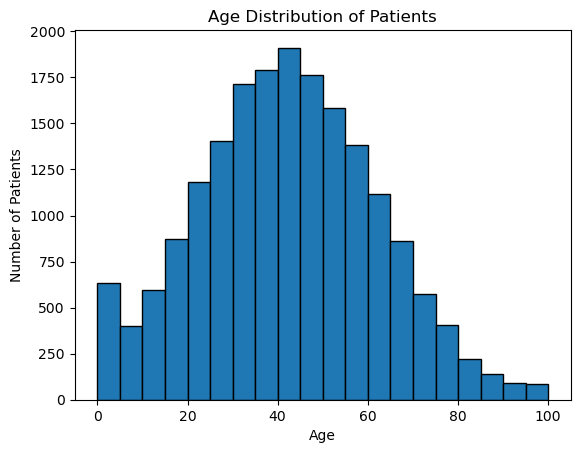

In [223]:
plt.hist(df_patient["age"], bins=range(0, 101, 5), edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Patients")

plt.show()

##### from histogram its cleared the age data is approximately normal distributed so
##### we will fill the null value as 

##### Age -> Mean
##### City, Gender, Blood group, Insurance type -> Mode
##### Phone -> Not Provided

In [224]:
for i in ("city", "gender", "blood_group", "insurance_type"):
    df_patient[i] = df_patient[i].fillna(df_patient[i].mode()[0])

df_patient["age"] = df_patient["age"].fillna(df_patient["age"].mean()).round().astype("int64")

df_patient["phone"] = df_patient["phone"].astype("Int64").astype("string").fillna("Not Provided")

#### Check

In [225]:
df_patient.isnull().sum()

patient_id           0
patient_name         0
gender               0
age                  0
blood_group          0
city                 0
phone                0
insurance_type       0
registration_date    0
dtype: int64

In [226]:
df_patient.duplicated().sum()

np.int64(0)

In [227]:
df_patient.dtypes

patient_id                    int64
patient_name                 object
gender               string[python]
age                           int64
blood_group                  object
city                 string[python]
phone                string[python]
insurance_type               object
registration_date    datetime64[ns]
dtype: object

In [228]:
for i in ('gender', 'city', 'blood_group', 'insurance_type'):
    print(i)
    print(df_patient[i].unique())
    print(df_patient[i].nunique())
    print()
    print("-"* 70)

gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: string
3

----------------------------------------------------------------------
city
<StringArray>
[    'Noida',     'Delhi',   'Lucknow',   'Chennai',   'Kolkata', 'Hyderabad',
    'Mumbai',    'Jaipur', 'Bengaluru',      'Pune']
Length: 10, dtype: string
10

----------------------------------------------------------------------
blood_group
['O+' 'A+' 'B-' 'AB-' 'O-' 'A-' 'B+' 'AB+']
8

----------------------------------------------------------------------
insurance_type
['Corporate' 'Private' 'Government']
3

----------------------------------------------------------------------


In [229]:
df_patient.describe()

,patient_id,age,registration_date
count,20000.000000,20000.000000,20000
mean,10000.500000,41.709850,2022-07-04 19:59:00.960000
min,1.000000,0.000000,2019-01-01 00:00:00
25%,5000.750000,29.000000,2020-10-07 00:00:00
50%,10000.500000,42.000000,2022-07-08 00:00:00
75%,15000.250000,54.000000,2024-04-01 00:00:00
max,20000.000000,100.000000,2025-12-30 00:00:00
std,5773.647028,19.061811,NaN


### ------------------------------------------------------------------------------------------

### Now our data is cleaned, consistent, having no duplicated data and having proper data type

### ------------------------------------------------------------------------------------------

## EXPLORING APPOINTMENT TABLE!

The purpose of exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [230]:
df_appointment.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_type,status,wait_time_min,satisfaction_score
0,1,11802,95.0,2023-12-22,Teleconsultation,Completed,15.0,5.0
1,2,718,74.0,2022-04-04,Consultation,COMPLETED,14.0,5.0
2,3,7870,210.0,2024-10-21,NaN,Completed,39.0,4.0
3,4,19623,135.0,2024-10-20,Follow-up,Completed,64.0,5.0
4,5,7950,52.0,10/09/2023,Consultation,Completed,20.0,3.0


### Lets see the shape and columns name

In [231]:
print(df_appointment.shape)
df_appointment.columns

(60000, 8)


Index(['appointment_id', 'patient_id', 'doctor_id', 'appointment_date',
       'appointment_type', 'status', 'wait_time_min', 'satisfaction_score'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [232]:
df_appointment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   appointment_id      60000 non-null  int64  
 1   patient_id          60000 non-null  int64  
 2   doctor_id           57585 non-null  float64
 3   appointment_date    60000 non-null  object 
 4   appointment_type    57633 non-null  object 
 5   status              60000 non-null  object 
 6   wait_time_min       57609 non-null  float64
 7   satisfaction_score  41997 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 3.7+ MB


### check for null value

In [233]:
df_appointment.isna().sum()

appointment_id            0
patient_id                0
doctor_id              2415
appointment_date          0
appointment_type       2367
status                    0
wait_time_min          2391
satisfaction_score    18003
dtype: int64

### Check for duplicate row

In [234]:
df_appointment.duplicated().sum()

np.int64(0)

In [235]:
df_appointment.describe()

,appointment_id,patient_id,doctor_id,wait_time_min,satisfaction_score
count,60000.000000,60000.000000,57585.000000,57609.000000,41997.000000
mean,30000.500000,10042.965783,125.843275,25.009078,3.751673
std,17320.652413,5811.280221,72.055795,38.843043,1.133498
min,1.000000,1.000000,1.000000,-10.000000,1.000000
25%,15000.750000,4989.000000,63.000000,11.000000,3.000000
50%,30000.500000,10031.500000,126.000000,20.000000,4.000000
75%,45000.250000,15116.000000,188.000000,32.000000,5.000000
max,60000.000000,20499.000000,250.000000,1440.000000,5.000000


### Check for data consistancy

In [236]:
for i in (df_appointment.columns):
    print(i)
    print(df_appointment[i].unique())
    print(df_appointment[i].nunique())
    print()
    print("-"* 70)

appointment_id
[    1     2     3 ... 59998 59999 60000]
60000

----------------------------------------------------------------------
patient_id
[11802   718  7870 ...  5698 18853  6735]
19135

----------------------------------------------------------------------
doctor_id
[ 95.  74. 210. 135.  52. 157.  66.  nan  89. 202. 101. 149.  57. 127.
 150. 160. 141. 244. 142.  42. 140.  99.  55.   9. 144.  94.  37. 200.
 192. 175. 102.  76.  77. 167. 222. 114.  53. 193. 208.  12. 153. 134.
 248. 205. 194. 165.  63. 206.  17.  32. 103.  22.  40. 136. 155. 231.
 120.  27. 188.  70. 138. 116. 237.  14.  60. 163. 123.  31. 178. 215.
 128.  28. 118.  98. 196.  48. 234. 181. 243.  29.  64.  84. 238. 250.
  47. 125. 197.  72. 239. 186.  93.  44.   1. 108.  97.  36. 235.   4.
 212. 177. 158. 131. 229. 228.  73. 247.  68. 201. 224. 199. 185. 209.
 174.  88.  67. 104.  25. 249. 226.  19.  10. 154. 207.   2.  54. 172.
  69. 225. 203. 115. 146. 213. 145. 232.  87.  79.  24.  49. 143. 109.
  41. 217.  91

## OBSERVATIONS :
#### 1 -> There are 60000 rows and 8 columns in this table

#### 2 -> Null values are present in: doctor_id (2415), appointment_type (2367), wait_time_min (2391), satisfaction_score (18003)

#### 3 -> satisfaction_score is null for appointments that are not Completed. This is natural (no visit = no rating), so we will **not** fill it

#### 4 -> status has inconsistent casing and extra spaces

#### 5 -> wait_time_min has 94 impossible values (negative or above 300 minutes)

#### 6 -> 150 appointments have a patient_id that does not exist in the patient table (orphan records)

#### 7 -> appointment_date is in object form and has mixed date formats

## CLEANING APPOINTMENT TABLE DATA

#### 1 - Changing Data Types of Columns in required form

In [237]:
df_appointment["appointment_date"] = parse_mixed_date(df_appointment["appointment_date"])
df_appointment.dtypes

appointment_id                 int64
patient_id                     int64
doctor_id                    float64
appointment_date      datetime64[ns]
appointment_type              object
status                        object
wait_time_min                float64
satisfaction_score           float64
dtype: object

### 2 - Deal with inconsistent value

In [238]:
df_appointment["status"] = df_appointment["status"].str.strip().str.title()
df_appointment["status"].unique()

array(['Completed', 'Cancelled', 'No-Show', 'Scheduled'], dtype=object)

### 3 - Deal with orphan records (broken foreign key)

These appointments belong to patients who are not in the patient table, so they cannot be analysed with patient information. We remove them.

In [239]:
orphan = ~df_appointment["patient_id"].isin(df_patient["patient_id"])
orphan.sum()

np.int64(150)

In [240]:
df_appointment = df_appointment[~orphan]

### 4 - Deal with impossible wait time

In [241]:
df_appointment.loc[(df_appointment["wait_time_min"] < 0) | (df_appointment["wait_time_min"] > 300), "wait_time_min"] = np.nan

### 5 - Deal with null value

In [242]:
df_appointment.isna().sum() * 100 / len(df_appointment)

appointment_id         0.000000
patient_id             0.000000
doctor_id              4.033417
appointment_date       0.000000
appointment_type       3.951546
status                 0.000000
wait_time_min          4.145363
satisfaction_score    30.013367
dtype: float64

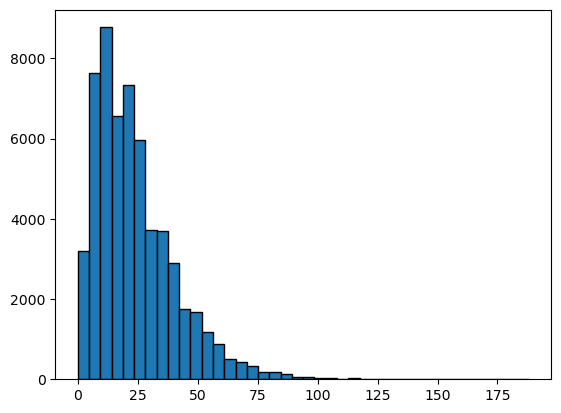

In [243]:
plt.hist(df_appointment["wait_time_min"].dropna(), bins=40, edgecolor="black")
plt.show()

##### wait time is right-skewed, so mean will be pulled by long waits. We will fill as

##### wait_time_min -> Median
##### appointment_type -> Mode
##### doctor_id -> we cannot guess which doctor treated the patient, so we drop these rows
##### satisfaction_score -> leave as null

In [244]:
df_appointment["wait_time_min"] = df_appointment["wait_time_min"].fillna(df_appointment["wait_time_min"].median())
df_appointment["appointment_type"] = df_appointment["appointment_type"].fillna(df_appointment["appointment_type"].mode()[0])

df_appointment = df_appointment.dropna(subset=["doctor_id"])
df_appointment["doctor_id"] = df_appointment["doctor_id"].astype("int64")
df_appointment['satisfaction_score'] = df_appointment['satisfaction_score'].fillna(0)

#### Check

In [245]:
df_appointment.isnull().sum()

appointment_id        0
patient_id            0
doctor_id             0
appointment_date      0
appointment_type      0
status                0
wait_time_min         0
satisfaction_score    0
dtype: int64

In [246]:
df_appointment.duplicated().sum()

np.int64(0)

In [247]:
df_appointment.dtypes

appointment_id                 int64
patient_id                     int64
doctor_id                      int64
appointment_date      datetime64[ns]
appointment_type              object
status                        object
wait_time_min                float64
satisfaction_score           float64
dtype: object

In [248]:
for i in (df_appointment.columns):
    print(i)
    print(df_appointment[i].unique())
    print(df_appointment[i].nunique())
    print()
    print("-"* 70)

appointment_id
[    1     2     3 ... 59998 59999 60000]
57436

----------------------------------------------------------------------
patient_id
[11802   718  7870 ...  1970  4945 18853]
18886

----------------------------------------------------------------------
doctor_id
[ 95  74 210 135  52 157  66  89 202 101 149  57 127 150 160 141 244 142
  42 140  99  55   9 144  94  37 200 192 175 102  76  77 167 222 114  53
 193 208  12 153 134 248 205 194 165  63 206  17  32 103  22  40 136 155
 231 120  27 188  70 138 116 237  14  60 163 123  31 178 215 128  28 118
  98 196  48 234 181 243  29  64  84 238 250  47 125 197  72 239 186  93
  44   1 108  97  36 235   4 212 177 158 131 229 228  73 247  68 201 224
 199 185 209 174  88  67 104  25 249 226  19  10 154 207   2  54 172  69
 225 203 115 146 213 145 232  87  79  24  49 143 109  41 217  91 148  85
 179 122  16 211 137 106 111 173 223  80 171  78  71 195 169  11   5 133
  56 113 246 220 236 164  21 129  18 198  81 180  50  30 184 191 12

### Now our data is cleaned, consistent, having no orphan record and having proper data type

### ------------------------------------------------------------------------------------------

# EXPLORING ADMISSION TABLE! 

The purpose of exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [249]:
df_admission.head()

,admission_id,patient_id,doctor_id,department_id,admission_date,discharge_date,diagnosis,admission_type,room_type,outcome
0,1,12764,13,9,2024-07-10,2024-07-15,Cardiac Arrest,Emergency,General,Recovered
1,2,1922,44,3,2023-07-02,2023-07-03,Kidney Stone,Planned,Private,Recovered
2,3,18982,162,12,2022-02-02,2022-02-04,Diabetes,Planned,General,Referred
3,4,18264,134,3,2023-10-05,2023-10-08,Cancer,Planned,ICU,Improved
4,5,11073,160,10,2023-08-08,2023-08-27,Diabetes,Emergency,Semi-Private,Improved


### Lets see the shape and columns name

In [250]:
print(df_admission.shape)
df_admission.columns

(24000, 10)


Index(['admission_id', 'patient_id', 'doctor_id', 'department_id',
       'admission_date', 'discharge_date', 'diagnosis', 'admission_type',
       'room_type', 'outcome'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [251]:
df_admission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   admission_id    24000 non-null  int64 
 1   patient_id      24000 non-null  int64 
 2   doctor_id       24000 non-null  int64 
 3   department_id   24000 non-null  int64 
 4   admission_date  24000 non-null  object
 5   discharge_date  23500 non-null  object
 6   diagnosis       23023 non-null  object
 7   admission_type  24000 non-null  object
 8   room_type       23068 non-null  object
 9   outcome         23057 non-null  object
dtypes: int64(4), object(6)
memory usage: 1.8+ MB


### check for null value

In [252]:
df_admission.isna().sum()

admission_id        0
patient_id          0
doctor_id           0
department_id       0
admission_date      0
discharge_date    500
diagnosis         977
admission_type      0
room_type         932
outcome           943
dtype: int64

### Check for duplicate row

In [253]:
df_admission.duplicated().sum()

np.int64(0)

### Check for data consistancy

In [254]:
for i in (df_admission.columns):
    print(i)
    print(df_admission[i].unique())
    print(df_admission[i].nunique())
    print()
    print("-"* 70)

admission_id
[    1     2     3 ... 23998 23999 24000]
24000

----------------------------------------------------------------------
patient_id
[12764  1922 18982 ...  1523   960  4922]
13966

----------------------------------------------------------------------
doctor_id
[ 13  44 162 134 160  72 168 178  67  20  37 194 227 132 158  78 193 220
  28  62 211  51  11 143 142 182 224 225 213  96  33 214 139 174  76 104
 147 203  90 205  97  32  63  49  57 204 161 221  54 122 138  69  87 128
 137  53 229   9  84 123  34  42 103 101  86 202  52  73  58 244 165 183
 238 241  16 208  25  38 176  50 106 179 157  89 177 125 218 223  45 153
 180  59 250 141 195  98 117 248   5 198 209  81  19 173 196 219 197 181
  35  39 163 149 187 145 109  80 115 240 156 207 231 152 189 148 166 150
  29 135 215  91 133  77  40 144 245   6 230 210 129  30  68  14  65 242
  83 100 140 246  88 233 131 190 206  43 243 164  75 175  12 201 236  15
 237  99 126 136  18  60 170 188  24  48 116  56  26  64 112 200 127 

## OBSERVATIONS :
#### 1 -> There are 24000 rows and 10 columns in this table

#### 2 -> Null values are present in: discharge_date (500), diagnosis (977), room_type (932), outcome (943)

#### 3 -> admission_date and discharge_date are in object form with mixed date formats

#### 4 -> diagnosis has inconsistent casing and spelling mistakes (Diabetis, Hypertention, Pnuemonia, Fractur)

#### 5 -> 77 rows have discharge_date **before** admission_date, which is logically impossible

#### 6 -> Null discharge_date can mean the patient is still admitted or the date was not recorded

## CLEANING ADMISSION TABLE DATA!

#### 1 - Changing Data Types of Columns in required form

In [255]:
df_admission["admission_date"] = parse_mixed_date(df_admission["admission_date"])
df_admission["discharge_date"] = parse_mixed_date(df_admission["discharge_date"])
df_admission.dtypes

admission_id               int64
patient_id                 int64
doctor_id                  int64
department_id              int64
admission_date    datetime64[ns]
discharge_date    datetime64[ns]
diagnosis                 object
admission_type            object
room_type                 object
outcome                   object
dtype: object

### 2 - Deal with inconsistent value

In [256]:
df_admission["diagnosis"] = df_admission["diagnosis"].str.strip().str.title()
df_admission["diagnosis"] = df_admission["diagnosis"].replace({
    "Diabetis": "Diabetes", "Hypertention": "Hypertension",
    "Pnuemonia": "Pneumonia", "Fractur": "Fracture", "Covid-19": "COVID-19"
})
df_admission["diagnosis"].unique()

array(['Cardiac Arrest', 'Kidney Stone', 'Diabetes', 'Cancer', 'Fever',
       'Hypertension', 'COVID-19', nan, 'Fracture', 'Maternity', 'Dengue',
       'Pneumonia', 'Appendicitis', 'Stroke', 'Asthma', 'Migraine'],
      dtype=object)

### 3 - Deal with illogical dates

A patient cannot leave before arriving. We treat the wrong discharge date as missing.

In [257]:
bad_dates = df_admission["discharge_date"] < df_admission["admission_date"]
bad_dates.sum()

np.int64(77)

In [258]:
df_admission.loc[bad_dates, "discharge_date"] = pd.NaT

### 4 - Deal with null value

##### discharge_date -> keep null (not discharged / not recorded), do not invent a date
##### diagnosis, outcome -> Unknown
##### room_type -> Mode

In [259]:
df_admission["diagnosis"] = df_admission["diagnosis"].fillna("Unknown")
df_admission["outcome"] = df_admission["outcome"].fillna("Unknown")
df_admission["room_type"] = df_admission["room_type"].fillna(df_admission["room_type"].mode()[0])

### 5 - Create length of stay

This will be used again in the analysis.

In [260]:
df_admission["length_of_stay"] = (df_admission["discharge_date"] - df_admission["admission_date"]).dt.days
df_admission["length_of_stay"].describe()

count    23423.000000
mean         5.011613
std          3.538985
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         31.000000
Name: length_of_stay, dtype: float64

#### Check

In [261]:
df_admission.isnull().sum()

admission_id        0
patient_id          0
doctor_id           0
department_id       0
admission_date      0
discharge_date    577
diagnosis           0
admission_type      0
room_type           0
outcome             0
length_of_stay    577
dtype: int64

In [262]:
df_admission.duplicated().sum()

np.int64(0)

In [263]:
df_admission.dtypes

admission_id               int64
patient_id                 int64
doctor_id                  int64
department_id              int64
admission_date    datetime64[ns]
discharge_date    datetime64[ns]
diagnosis                 object
admission_type            object
room_type                 object
outcome                   object
length_of_stay           float64
dtype: object

In [264]:
for i in (df_admission.columns):
    print(i)
    print(df_admission[i].unique())
    print(df_admission[i].nunique())
    print()
    print("-"* 70)

admission_id
[    1     2     3 ... 23998 23999 24000]
24000

----------------------------------------------------------------------
patient_id
[12764  1922 18982 ...  1523   960  4922]
13966

----------------------------------------------------------------------
doctor_id
[ 13  44 162 134 160  72 168 178  67  20  37 194 227 132 158  78 193 220
  28  62 211  51  11 143 142 182 224 225 213  96  33 214 139 174  76 104
 147 203  90 205  97  32  63  49  57 204 161 221  54 122 138  69  87 128
 137  53 229   9  84 123  34  42 103 101  86 202  52  73  58 244 165 183
 238 241  16 208  25  38 176  50 106 179 157  89 177 125 218 223  45 153
 180  59 250 141 195  98 117 248   5 198 209  81  19 173 196 219 197 181
  35  39 163 149 187 145 109  80 115 240 156 207 231 152 189 148 166 150
  29 135 215  91 133  77  40 144 245   6 230 210 129  30  68  14  65 242
  83 100 140 246  88 233 131 190 206  43 243 164  75 175  12 201 236  15
 237  99 126 136  18  60 170 188  24  48 116  56  26  64 112 200 127 

### Now our data is cleaned and consistent (only discharge_date / length_of_stay keep nulls on purpose)

## ---------------------------------------------------------------------------------------

# EXPLORING BILLING TABLE!

The purpose of exploring is to get a quick overview of the data and identify any potential problems or areas of interest.

In [265]:
df_billing.head()

,bill_id,admission_id,patient_id,total_amount,insurance_covered,payment_method,payment_status,bill_date
0,1,1,12764,32726.66,5650.430,Insurance,Paid,2022-01-17
1,2,2,1922,12985.71,682.670,card,Overdue,2023-05-03
2,3,3,18982,8364.84,5343.080,UPI,Pending,2023-10-29
3,4,4,18264,55955.21,46164.380,Card,Paid,2023-03-19
4,5,5,11073,119264.23,178896.345,Cash,Pending,2022-10-27


### Lets see the shape and columns name

In [266]:
print(df_billing.shape)
df_billing.columns

(24000, 8)


Index(['bill_id', 'admission_id', 'patient_id', 'total_amount',
       'insurance_covered', 'payment_method', 'payment_status', 'bill_date'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [267]:
df_billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_id            24000 non-null  int64  
 1   admission_id       24000 non-null  int64  
 2   patient_id         24000 non-null  int64  
 3   total_amount       23004 non-null  float64
 4   insurance_covered  23048 non-null  float64
 5   payment_method     23079 non-null  object 
 6   payment_status     24000 non-null  object 
 7   bill_date          24000 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 1.5+ MB


### check for null value

In [268]:
df_billing.isna().sum()

bill_id                0
admission_id           0
patient_id             0
total_amount         996
insurance_covered    952
payment_method       921
payment_status         0
bill_date              0
dtype: int64

### Check for duplicate row

In [269]:
df_billing.duplicated().sum()

np.int64(0)

In [270]:
df_billing.describe()

,bill_id,admission_id,patient_id,total_amount,insurance_covered
count,24000.000000,24000.000000,24000.000000,2.300400e+04,2.304800e+04
mean,12000.500000,12000.500000,9990.314500,1.994947e+05,2.019834e+04
std,6928.347566,6928.347566,5807.404645,4.112930e+06,9.880962e+05
min,1.000000,1.000000,1.000000,-5.000000e+03,-7.500000e+03
25%,6000.750000,6000.750000,4927.000000,1.429179e+04,4.089120e+03
50%,12000.500000,12000.500000,10007.500000,2.206415e+04,8.916615e+03
75%,18000.250000,18000.250000,15030.000000,3.477482e+04,1.676415e+04
max,24000.000000,24000.000000,19998.000000,1.000000e+08,1.500000e+08


### Check for data consistancy

In [271]:
for i in (df_billing.columns):
    print(i)
    print(df_billing[i].unique())
    print(df_billing[i].nunique())
    print()
    print("-"* 70)

bill_id
[    1     2     3 ... 23998 23999 24000]
24000

----------------------------------------------------------------------
admission_id
[    1     2     3 ... 23998 23999 24000]
24000

----------------------------------------------------------------------
patient_id
[12764  1922 18982 ...  1523   960  4922]
13966

----------------------------------------------------------------------
total_amount
[32726.66 12985.71  8364.84 ... 59094.48  9462.1  22347.95]
22849

----------------------------------------------------------------------
insurance_covered
[ 5650.43   682.67  5343.08 ... 20601.85  3786.22 15373.45]
22929

----------------------------------------------------------------------
payment_method
['Insurance' 'card' 'UPI' 'Card' 'Cash' 'Net Banking' ' Net Banking '
 'net banking' 'upi' 'CARD' nan ' Cash ' ' Card ' 'CASH' 'insurance'
 'INSURANCE' 'NET BANKING' ' Insurance ' ' UPI ' 'cash']
19

----------------------------------------------------------------------
payment_status


## OBSERVATIONS :
#### 1 -> There are 24000 rows and 8 columns in this table

#### 2 -> Null values are present in: total_amount (996), insurance_covered (952), payment_method (921)

#### 3 -> total_amount has 112 invalid values (zero, negative or extremely large like 99999999)

#### 4 -> 160 bills have insurance_covered **greater than** total_amount

#### 5 -> payment_method has inconsistent casing and extra spaces

#### 6 -> bill_date is in object form with mixed date formats

## CLEANING BILLING TABLE DATA

#### 1 - Changing Data Types of Columns in required form

In [272]:
df_billing["bill_date"] = parse_mixed_date(df_billing["bill_date"])
df_billing.dtypes

bill_id                       int64
admission_id                  int64
patient_id                    int64
total_amount                float64
insurance_covered           float64
payment_method               object
payment_status               object
bill_date            datetime64[ns]
dtype: object

### 2 - Deal with inconsistent value

In [273]:
df_billing["payment_method"] = df_billing["payment_method"].str.strip().str.title()
df_billing["payment_method"] = df_billing["payment_method"].replace({"Upi": "UPI"})
df_billing["payment_method"].unique()

array(['Insurance', 'Card', 'UPI', 'Cash', 'Net Banking', nan],
      dtype=object)

### 3 - Deal with invalid amounts

A hospital bill cannot be zero, negative or in crores for a normal stay, so we treat them as missing.

In [274]:
bad_amt = (df_billing["total_amount"] <= 0) | (df_billing["total_amount"] > 2000000)
bad_amt.sum()

np.int64(112)

In [275]:
df_billing.loc[bad_amt, "total_amount"] = np.nan

### 4 - Deal with null value

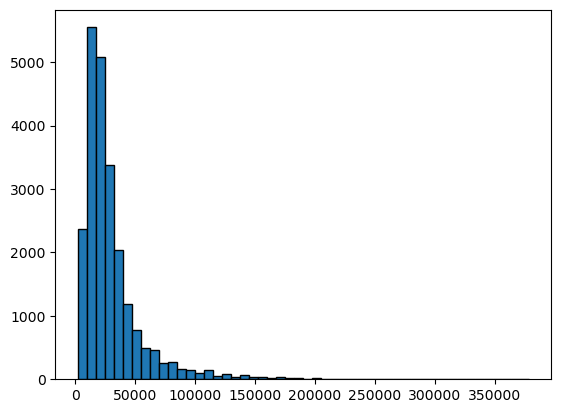

In [276]:
plt.hist(df_billing["total_amount"].dropna(), bins=50, edgecolor='black')
plt.show()

##### bill amount is right-skewed, so we will fill as

##### total_amount -> Median
##### insurance_covered -> Median
##### payment_method -> Mode

In [277]:
df_billing["total_amount"] = df_billing["total_amount"].fillna(df_billing["total_amount"].median())
df_billing["insurance_covered"] = df_billing["insurance_covered"].fillna(df_billing["insurance_covered"].median())
df_billing["payment_method"] = df_billing["payment_method"].fillna(df_billing["payment_method"].mode()[0])

### 5 - Insurance cannot cover more than the bill

We cap insurance_covered at total_amount.

In [278]:
print((df_billing["insurance_covered"] > df_billing["total_amount"]).sum())
df_billing["insurance_covered"] = np.minimum(df_billing["insurance_covered"], df_billing["total_amount"])

352


#### Check

In [279]:
df_billing.isnull().sum()

bill_id              0
admission_id         0
patient_id           0
total_amount         0
insurance_covered    0
payment_method       0
payment_status       0
bill_date            0
dtype: int64

In [280]:
df_billing.duplicated().sum()

np.int64(0)

In [281]:
df_billing.dtypes

bill_id                       int64
admission_id                  int64
patient_id                    int64
total_amount                float64
insurance_covered           float64
payment_method               object
payment_status               object
bill_date            datetime64[ns]
dtype: object

In [282]:
for i in ('payment_method', 'payment_status'):
    print(i)
    print(df_billing[i].unique())
    print(df_billing[i].nunique())
    print()
    print("-"* 70)

payment_method
['Insurance' 'Card' 'UPI' 'Cash' 'Net Banking']
5

----------------------------------------------------------------------
payment_status
['Paid' 'Overdue' 'Pending' 'Partial']
4

----------------------------------------------------------------------


In [283]:
df_billing.describe()

,bill_id,admission_id,patient_id,total_amount,insurance_covered,bill_date
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000
mean,12000.500000,12000.500000,9990.314500,29742.500851,13263.979487,2023-12-31 13:39:43.200000
min,1.000000,1.000000,1.000000,2101.960000,-7500.000000,2022-01-01 00:00:00
25%,6000.750000,6000.750000,4927.000000,14727.670000,4243.602500,2023-01-05 00:00:00
50%,12000.500000,12000.500000,10007.500000,22092.405000,8916.615000,2023-12-31 00:00:00
75%,18000.250000,18000.250000,15030.000000,33807.622500,16293.030000,2024-12-25 00:00:00
max,24000.000000,24000.000000,19998.000000,378390.710000,243223.550000,2025-12-30 00:00:00
std,6928.347566,6928.347566,5807.404645,27425.489155,16022.601331,NaN


## --------------------------------------------------------------------------------------

### Now our data is cleaned, consistent, having no null value and having proper data type

## -----------------------------------------------------------------------------------------

# EXPLORING LAB TABLE!

In [284]:
df_lab.head()

,lab_id,patient_id,admission_id,test_name,result_value,unit,test_date,cost,result_flag
0,1,11557,701.0,Platelets,NaN,cells/uL,2024-01-08,200.0,Abnormal
1,2,8614,7456.0,creatinine,0.46,mg/dL,2022-09-21,800.0,Abnormal
2,3,8815,13967.0,Creatinine,0.74,mg/dL,2025-06-17,500.0,Normal
3,4,10013,11972.0,Hemoglobin,10.76,g/dL,2024-08-12,200.0,Abnormal
4,5,12788,13463.0,Cholesterol,162.26,mg/dL,2024-10-24,350.0,Normal


### Lets see the shape and columns name

In [285]:
print(df_lab.shape)
df_lab.columns

(50000, 9)


Index(['lab_id', 'patient_id', 'admission_id', 'test_name', 'result_value',
       'unit', 'test_date', 'cost', 'result_flag'],
      dtype='object')

### Let's have a look on the columns and their data types using detailed info function

In [286]:
df_lab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lab_id        50000 non-null  int64  
 1   patient_id    50000 non-null  int64  
 2   admission_id  47448 non-null  float64
 3   test_name     50000 non-null  object 
 4   result_value  47516 non-null  float64
 5   unit          50000 non-null  object 
 6   test_date     50000 non-null  object 
 7   cost          47446 non-null  float64
 8   result_flag   50000 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.4+ MB


### check for null value

In [287]:
df_lab.isna().sum()

lab_id             0
patient_id         0
admission_id    2552
test_name          0
result_value    2484
unit               0
test_date          0
cost            2554
result_flag        0
dtype: int64

### Check for duplicate row

In [288]:
df_lab.duplicated().sum()

np.int64(0)

In [289]:
df_lab.describe()

,lab_id,patient_id,admission_id,result_value,cost
count,50000.000000,50000.000000,47448.000000,47516.000000,47446.000000
mean,25000.500000,10019.691700,12027.665697,51829.306366,613.572272
std,14433.901067,5773.080541,6915.010659,122280.996095,356.315960
min,1.000000,1.000000,1.000000,-200470.160000,200.000000
25%,12500.750000,5050.000000,6048.000000,14.420000,350.000000
50%,25000.500000,10015.500000,12016.000000,131.740000,500.000000
75%,37500.250000,15035.000000,17988.000000,7537.345000,800.000000
max,50000.000000,20000.000000,24000.000000,831118.540000,1200.000000


### Check for data consistancy

In [290]:
for i in ('test_name', 'unit', 'result_flag'):
    print(i)
    print(df_lab[i].unique())
    print(df_lab[i].nunique())
    print()
    print("-"* 70)

test_name
['Platelets' 'creatinine' 'Creatinine' 'Hemoglobin' 'Cholesterol'
 'WBC Count' 'Blood Sugar' ' Blood Sugar ' ' Cholesterol ' 'platelets'
 'PLATELETS' 'blood sugar' 'wbc count' 'CREATININE' 'cholesterol'
 'hemoglobin' ' Platelets ' ' WBC Count ' ' Creatinine ' ' Hemoglobin '
 'CHOLESTEROL' 'WBC COUNT' 'HEMOGLOBIN' 'BLOOD SUGAR']
24

----------------------------------------------------------------------
unit
['cells/uL' 'mg/dL' 'g/dL']
3

----------------------------------------------------------------------
result_flag
['Abnormal' 'Normal']
2

----------------------------------------------------------------------


## OBSERVATIONS :
#### 1 -> There are 50000 rows and 9 columns in this table

#### 2 -> Null values are present in: admission_id (2469), result_value (2472), cost (2527)

#### 3 -> 140 rows have result_value = -999, which is a placeholder for a failed test, not a real result

#### 4 -> test_name has inconsistent casing and extra spaces

#### 5 -> result_flag was calculated on the original value, so it is wrong for the -999 rows. We will recalculate it after cleaning

#### 6 -> Null admission_id may mean an OPD (outpatient) test, so we keep it null

#### 7 -> test_date is in object form with mixed date formats

## CLEANING LAB TABLE DATA

#### 1 - Changing Data Types of Columns in required form

In [291]:
df_lab["test_date"] = parse_mixed_date(df_lab["test_date"])
df_lab.dtypes

lab_id                   int64
patient_id               int64
admission_id           float64
test_name               object
result_value           float64
unit                    object
test_date       datetime64[ns]
cost                   float64
result_flag             object
dtype: object

### 2 - Deal with inconsistent value

In [292]:
df_lab["test_name"] = df_lab["test_name"].str.strip().str.title()
df_lab["test_name"] = df_lab["test_name"].replace({"Wbc Count": "WBC Count"})
df_lab["test_name"].unique()

array(['Platelets', 'Creatinine', 'Hemoglobin', 'Cholesterol',
       'WBC Count', 'Blood Sugar'], dtype=object)

### 3 - Deal with placeholder value (-999)

In [293]:
(df_lab["result_value"] == -999).sum()

np.int64(143)

In [294]:
df_lab["result_value"] = df_lab["result_value"].replace(-999, np.nan)

### 4 - Deal with null value

Every test has a different scale (Platelets in lakhs, Creatinine below 2), so a single mean/median for the whole column would be wrong.
We fill each test with **its own median**.

##### result_value -> Median of that test
##### cost -> Median
##### admission_id -> keep null (OPD tests)

In [295]:
df_lab["result_value"] = df_lab["result_value"].fillna(df_lab.groupby("test_name")["result_value"].transform("median"))
df_lab["cost"] = df_lab["cost"].fillna(df_lab["cost"].median())

### 5 - Recalculate result_flag using normal reference ranges

In [296]:
ref_range = {
    "Blood Sugar": (70, 140), "Hemoglobin": (12, 17), "Cholesterol": (125, 200),
    "Creatinine": (0.6, 1.3), "WBC Count": (4000, 11000), "Platelets": (150000, 450000)
}

low = df_lab["test_name"].map(lambda x: ref_range[x][0])
high = df_lab["test_name"].map(lambda x: ref_range[x][1])

df_lab["result_flag"] = np.where(df_lab["result_value"].between(low, high), "Normal", "Abnormal")
df_lab["result_flag"].value_counts()

result_flag
Normal      40144
Abnormal     9856
Name: count, dtype: int64

#### Check

In [297]:
df_lab.isnull().sum()

lab_id             0
patient_id         0
admission_id    2552
test_name          0
result_value       0
unit               0
test_date          0
cost               0
result_flag        0
dtype: int64

In [298]:
df_lab.duplicated().sum()

np.int64(0)

In [299]:
df_lab.dtypes

lab_id                   int64
patient_id               int64
admission_id           float64
test_name               object
result_value           float64
unit                    object
test_date       datetime64[ns]
cost                   float64
result_flag             object
dtype: object

In [300]:
for i in ('test_name', 'result_flag'):
    print(i)
    print(df_lab[i].unique())
    print(df_lab[i].nunique())
    print()
    print("-"* 70)

test_name
['Platelets' 'Creatinine' 'Hemoglobin' 'Cholesterol' 'WBC Count'
 'Blood Sugar']
6

----------------------------------------------------------------------
result_flag
['Normal' 'Abnormal']
2

----------------------------------------------------------------------


### Now our data is cleaned and consistent (admission_id keeps nulls on purpose for OPD tests)

## ---------------------------------------------------------------------------------

## Checking relationship between tables (foreign keys)

Before merging, we check that every foreign key really exists in its parent table.

In [301]:
print("appointment -> patient :", (~df_appointment["patient_id"].isin(df_patient["patient_id"])).sum())
print("appointment -> doctor  :", (~df_appointment["doctor_id"].isin(df_doctor["doctor_id"])).sum())
print("admission -> patient   :", (~df_admission["patient_id"].isin(df_patient["patient_id"])).sum())
print("admission -> doctor    :", (~df_admission["doctor_id"].isin(df_doctor["doctor_id"])).sum())
print("admission -> department:", (~df_admission["department_id"].isin(df_department["department_id"])).sum())
print("billing -> admission   :", (~df_billing["admission_id"].isin(df_admission["admission_id"])).sum())
print("lab -> admission       :", (~df_lab["admission_id"].dropna().isin(df_admission["admission_id"])).sum())

appointment -> patient : 0
appointment -> doctor  : 0
admission -> patient   : 0
admission -> doctor    : 0
admission -> department: 0
billing -> admission   : 0
lab -> admission       : 0


## Merging the tables

The **admission** table is our main table (one row = one hospital stay).

Lab tests are many per admission, so if we merge them directly the rows will multiply and bills will be counted again and again.
So first we **summarise lab tests per admission**, then merge.

In [302]:
lab_summary = df_lab.groupby("admission_id").agg(
    total_tests=("lab_id", "count"),
    abnormal_tests=("result_flag", lambda x: (x == "Abnormal").sum()),
    lab_cost=("cost", "sum")
).reset_index()

In [303]:
final_df = (
    df_admission
    .merge(df_patient, on="patient_id", how="left")
    .merge(df_doctor[["doctor_id", "doctor_name", "specialization", "experience_years", "consultation_fee"]],
           on="doctor_id", how="left")
    .merge(df_department[["department_id", "department_name", "floor", "bed_capacity"]],
           on="department_id", how="left")
    .merge(df_billing.drop(columns="patient_id"), on="admission_id", how="left")
    .merge(lab_summary, on="admission_id", how="left")
)

final_df[["total_tests", "abnormal_tests", "lab_cost"]] = final_df[["total_tests", "abnormal_tests", "lab_cost"]].fillna(0)
print(final_df.shape)
print(final_df["admission_id"].is_unique)   # must be True, no row multiplication

(24000, 35)
True


In [304]:
final_df.head()

,admission_id,patient_id,doctor_id,department_id,admission_date,discharge_date,diagnosis,admission_type,room_type,outcome,length_of_stay,patient_name,gender,age,blood_group,city,phone,insurance_type,registration_date,doctor_name,specialization,experience_years,consultation_fee,department_name,floor,bed_capacity,bill_id,total_amount,insurance_covered,payment_method,payment_status,bill_date,total_tests,abnormal_tests,lab_cost
0,1,12764,13,9,2024-07-10,2024-07-15,Cardiac Arrest,Emergency,General,Recovered,5.0,Arjun Gupta,Male,44,AB+,Mumbai,9973265174,Private,2023-06-07,Dr. Neha Khan,Surgeon,29,1500,Psychiatry,2,73,1,32726.66,5650.43,Insurance,Paid,2022-01-17,2.0,1.0,1150.0
1,2,1922,44,3,2023-07-02,2023-07-03,Kidney Stone,Planned,Private,Recovered,1.0,Deepak Kapoor,Male,35,AB-,Bengaluru,9815121126,Private,2023-05-15,Dr. Anjali Mehta,Resident,35,1500,Orthopedics,5,31,2,12985.71,682.67,Card,Overdue,2023-05-03,1.0,0.0,500.0
2,3,18982,162,12,2022-02-02,2022-02-04,Diabetes,Planned,General,Referred,2.0,Amit Nair,Female,25,B+,Jaipur,9723917746,Private,2024-05-05,Dr. Isha Nair,Specialist,28,1000,Urology,3,42,3,8364.84,5343.08,UPI,Pending,2023-10-29,1.0,0.0,800.0
3,4,18264,134,3,2023-10-05,2023-10-08,Cancer,Planned,ICU,Improved,3.0,Amit Das,Female,39,O+,Noida,9348367094,Private,2021-04-25,Dr. Sneha Verma,Consultant,36,300,Orthopedics,5,31,4,55955.21,46164.38,Card,Paid,2023-03-19,1.0,0.0,500.0
4,5,11073,160,10,2023-08-08,2023-08-27,Diabetes,Emergency,Semi-Private,Improved,19.0,Deepak Joshi,Male,22,A+,Noida,9962434506,Private,2021-04-20,Dr. Deepak Patel,Specialist,8,800,Radiology,3,69,5,119264.23,119264.23,Cash,Pending,2022-10-27,2.0,0.0,1000.0


### Appointment table has a different grain (one row = one OPD visit), so we keep a separate analysis table for it

In [305]:
appt_df = (
    df_appointment
    .merge(df_patient, on="patient_id", how="left")
    .merge(df_doctor[["doctor_id", "doctor_name", "department_id", "consultation_fee"]], on="doctor_id", how="left")
    .merge(df_department[["department_id", "department_name"]], on="department_id", how="left")
)
appt_df.shape

(57436, 20)

### Feature Engineering

In [306]:
final_df["admission_year"] = final_df["admission_date"].dt.year
final_df["admission_month"] = final_df["admission_date"].dt.month

# money the patient actually has to pay
final_df["patient_payable"] = final_df["total_amount"] - final_df["insurance_covered"]

# insurance coverage percentage
final_df["coverage_pct"] = final_df["insurance_covered"] / final_df["total_amount"] * 100

# cost per day of stay
final_df["cost_per_day"] = final_df["total_amount"] / final_df["length_of_stay"]

# age group
final_df["age_group"] = pd.cut(final_df["age"], bins=[-1, 12, 25, 40, 60, 100],
                               labels=["Child (0-12)", "Young (13-25)", "Adult (26-40)", "Middle (41-60)", "Senior (60+)"])
appt_df["appointment_month"] = appt_df["appointment_date"].dt.month
appt_df["appointment_year"] = appt_df["appointment_date"].dt.year

## Univariate Analysis

### 1. Numerical columns

In [307]:
num_col = final_df.select_dtypes(include = "number").columns
num_col

Index(['admission_id', 'patient_id', 'doctor_id', 'department_id',
       'length_of_stay', 'age', 'experience_years', 'consultation_fee',
       'floor', 'bed_capacity', 'bill_id', 'total_amount', 'insurance_covered',
       'total_tests', 'abnormal_tests', 'lab_cost', 'admission_year',
       'admission_month', 'patient_payable', 'coverage_pct', 'cost_per_day'],
      dtype='object')

#### A. Statistical summary

In [308]:
final_df.describe()

,admission_id,patient_id,doctor_id,department_id,admission_date,discharge_date,length_of_stay,age,registration_date,experience_years,consultation_fee,floor,bed_capacity,bill_id,total_amount,insurance_covered,bill_date,total_tests,abnormal_tests,lab_cost,admission_year,admission_month,patient_payable,coverage_pct,cost_per_day
count,24000.000000,24000.000000,24000.000000,24000.000000,24000,23423,23423.000000,24000.000000,24000,24000.000000,24000.000000,24000.000000,24000.00000,24000.000000,24000.000000,24000.000000,24000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,23423.000000
mean,12000.500000,9990.314500,125.897750,7.988500,2024-01-03 01:36:43.200000256,2024-01-07 12:55:36.412927488,5.011613,41.596458,2022-07-05 04:57:28.800000,20.935875,1027.466667,4.670542,40.98125,12000.500000,29742.500851,13263.979487,2023-12-31 13:39:43.200000,1.977000,0.390750,1201.125000,2023.507083,6.510375,16478.521364,45.245492,7131.649744
min,1.000000,1.000000,1.000000,1.000000,2022-01-01 00:00:00,2022-01-02 00:00:00,1.000000,0.000000,2019-01-01 00:00:00,1.000000,300.000000,2.000000,11.00000,1.000000,2101.960000,-7500.000000,2022-01-01 00:00:00,0.000000,0.000000,0.000000,2022.000000,1.000000,0.000000,-33.948318,789.014464
25%,6000.750000,4927.000000,64.000000,4.000000,2023-01-05 00:00:00,2023-01-10 00:00:00,2.000000,29.000000,2020-10-06 00:00:00,12.000000,500.000000,3.000000,30.00000,6000.750000,14727.670000,4243.602500,2023-01-05 00:00:00,1.000000,0.000000,400.000000,2023.000000,4.000000,5895.887500,22.320656,3698.855667
50%,12000.500000,10007.500000,126.000000,8.000000,2024-01-04 00:00:00,2024-01-08 00:00:00,4.000000,42.000000,2022-07-11 00:00:00,21.000000,800.000000,5.000000,39.00000,12000.500000,22092.405000,8916.615000,2023-12-31 00:00:00,2.000000,0.000000,1050.000000,2024.000000,7.000000,11361.015000,44.581925,5523.101250
75%,18000.250000,15030.000000,189.000000,12.000000,2025-01-03 00:00:00,2025-01-07 12:00:00,7.000000,54.000000,2024-03-28 00:00:00,31.000000,1500.000000,7.000000,62.00000,18000.250000,33807.622500,16293.030000,2024-12-25 00:00:00,3.000000,1.000000,1750.000000,2025.000000,10.000000,19767.022500,67.508428,8366.337500
max,24000.000000,19998.000000,250.000000,15.000000,2025-12-30 00:00:00,2026-01-22 00:00:00,31.000000,100.000000,2025-12-30 00:00:00,39.000000,2000.000000,7.000000,73.00000,24000.000000,378390.710000,243223.550000,2025-12-30 00:00:00,9.000000,5.000000,6500.000000,2025.000000,12.000000,287113.885000,100.000000,44402.640000
std,6928.347566,5807.404645,72.096038,4.326476,NaN,NaN,3.538985,19.105405,NaN,11.180536,590.250737,1.654347,20.44988,6928.347566,27425.489155,16022.601331,NaN,1.402992,0.619675,978.349626,1.116767,3.443649,18898.731241,26.524471,5006.493827


#### B. Distribution — Histogram

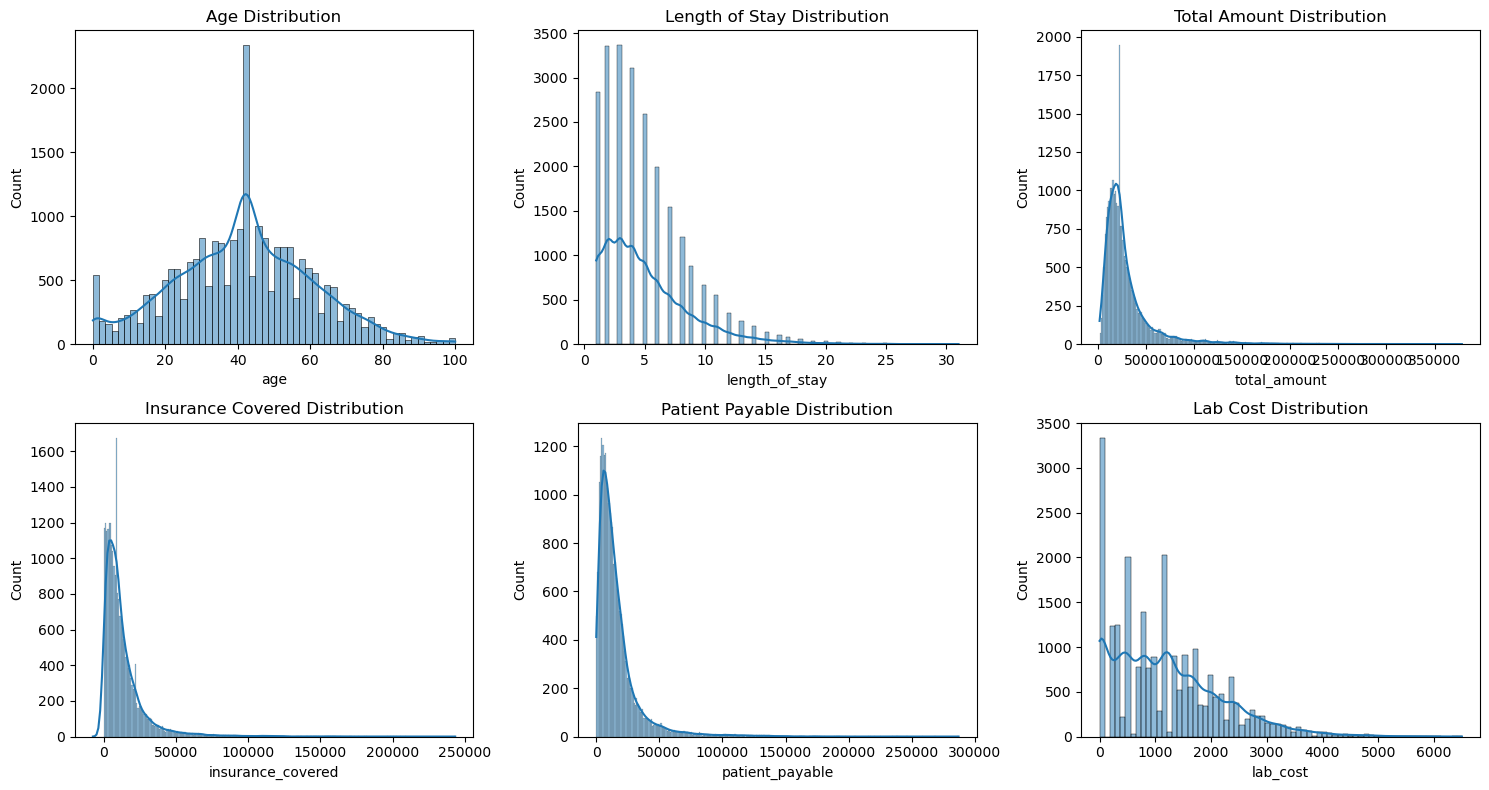

In [309]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(data=final_df, x="age", kde=True, ax=axes[0, 0]).set_title("Age Distribution")
sns.histplot(data=final_df, x="length_of_stay", kde=True, ax=axes[0, 1]).set_title("Length of Stay Distribution")
sns.histplot(data=final_df, x="total_amount", kde=True, ax=axes[0, 2]).set_title("Total Amount Distribution")
sns.histplot(data=final_df, x="insurance_covered", kde=True, ax=axes[1, 0]).set_title("Insurance Covered Distribution")
sns.histplot(data=final_df, x="patient_payable", kde=True, ax=axes[1, 1]).set_title("Patient Payable Distribution")
sns.histplot(data=final_df, x="lab_cost", kde=True, ax=axes[1, 2]).set_title("Lab Cost Distribution")
plt.tight_layout()
plt.show()

#### C. Outlier — Boxplot

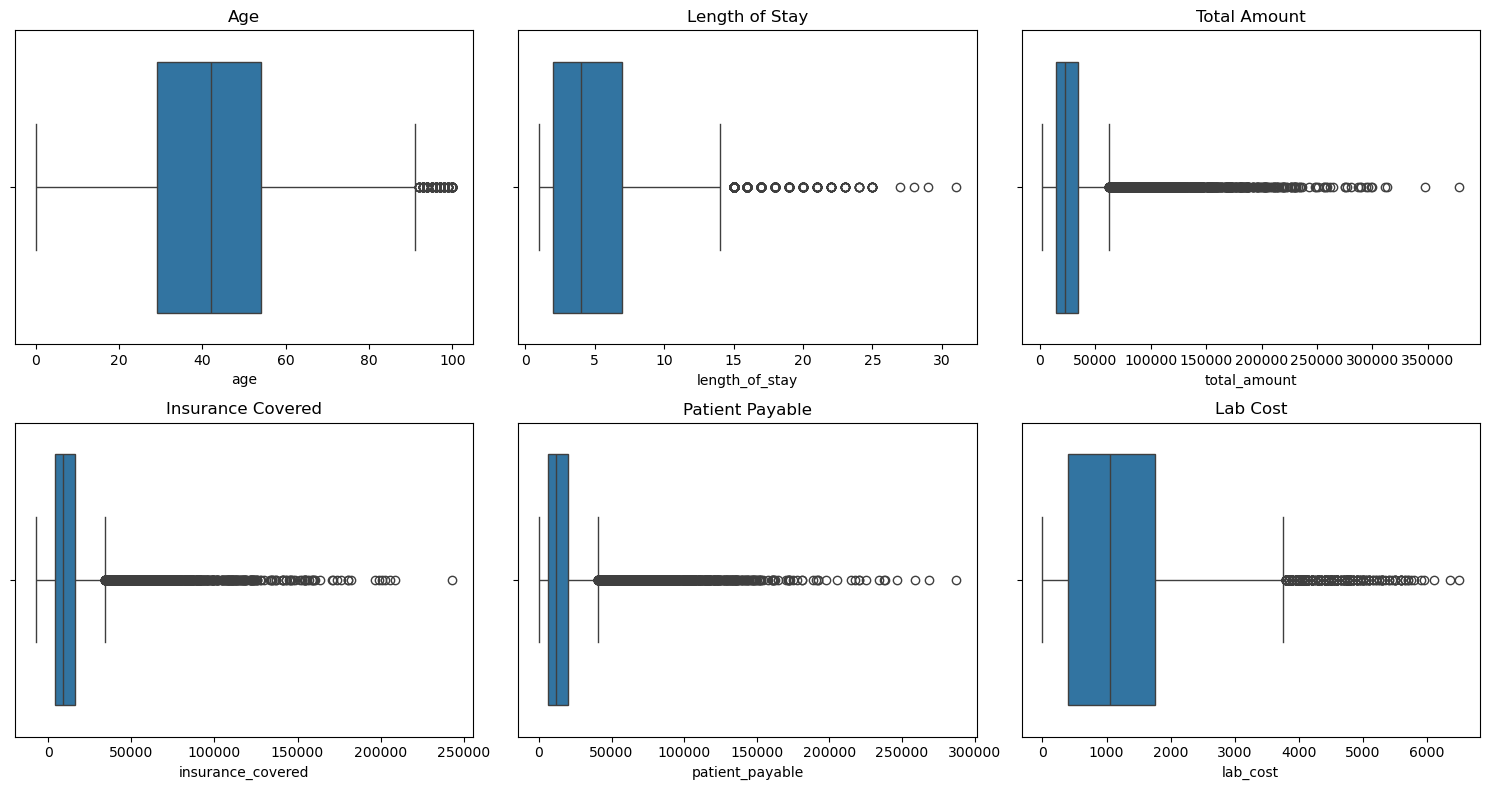

In [310]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(data=final_df, x="age", ax=axes[0, 0]).set_title("Age")
sns.boxplot(data=final_df, x="length_of_stay", ax=axes[0, 1]).set_title("Length of Stay")
sns.boxplot(data=final_df, x="total_amount", ax=axes[0, 2]).set_title("Total Amount")
sns.boxplot(data=final_df, x="insurance_covered", ax=axes[1, 0]).set_title("Insurance Covered")
sns.boxplot(data=final_df, x="patient_payable", ax=axes[1, 1]).set_title("Patient Payable")
sns.boxplot(data=final_df, x="lab_cost", ax=axes[1, 2]).set_title("Lab Cost")
plt.tight_layout()
plt.show()

# Insights
1. Age:\
Patient ages show variation across the dataset, with the boxplot helping identify the typical age range and potential age-related outliers.

2. Length of Stay\
Length of stay should be monitored for unusually high values, as prolonged hospitalizations can contribute significantly to healthcare resource utilization.

3. Total Amount\
Total treatment costs may be influenced by a smaller number of high-cost patients, making outlier analysis important when evaluating hospital revenue and expenses.

4. Insurance Covered\
Insurance coverage varies across patients, with extreme values potentially reflecting high-cost treatments or differences in coverage.

5. Patient Payable\
Patient payable amounts show variation across hospital visits, with high-value cases indicating potentially significant out-of-pocket financial burden.

6. Lab Cost\
Lab costs vary across patients, and extreme values may indicate cases requiring extensive diagnostic testing.

## Outlier Treatment

Extreme observations should be reviewed using statistical methods **and** business rules.
Clearly invalid values are already handled in the cleaning stage, while genuine high-value cases (long ICU stays, big surgeries) are **not** removed only because they are statistical outliers.

In [311]:
# business rule validation on the final table
print("Negative length of stay :", (final_df["length_of_stay"] < 0).sum())
print("Negative patient payable:", (final_df["patient_payable"] < 0).sum())
print("Age outside 0-100       :", (~final_df["age"].between(0, 100)).sum())

Negative length of stay : 0
Negative patient payable: 0
Age outside 0-100       : 0


### 2. Categorical columns

In [312]:
cat_columns = final_df.select_dtypes(include = "object").columns
cat_columns

Index(['diagnosis', 'admission_type', 'room_type', 'outcome', 'patient_name',
       'blood_group', 'insurance_type', 'doctor_name', 'specialization',
       'department_name', 'payment_method', 'payment_status'],
      dtype='object')

### countplot of important data

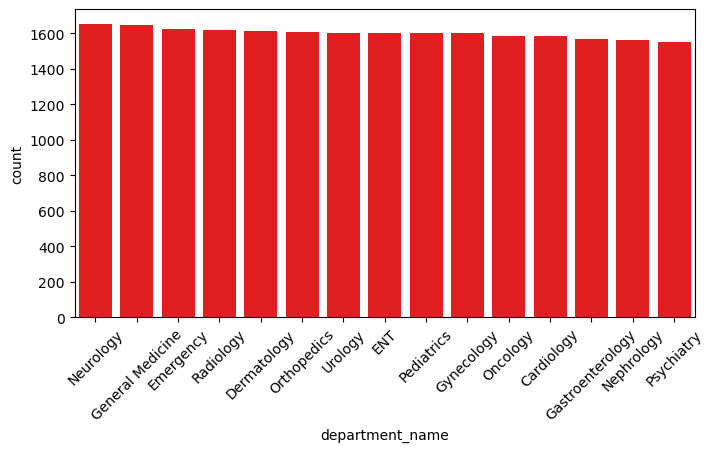

In [313]:
# department countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="department_name", color="red", order=final_df["department_name"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Department-wise Analysis

• Neurology has the highest number of records (~1,650).\
• General Medicine follows closely behind (~1,640).\
• Emergency and Radiology also have relatively high counts.\
• Psychiatry has the lowest count (~1,550).\
• Overall, department counts are fairly evenly distributed.\
• There is no major imbalance between departments.

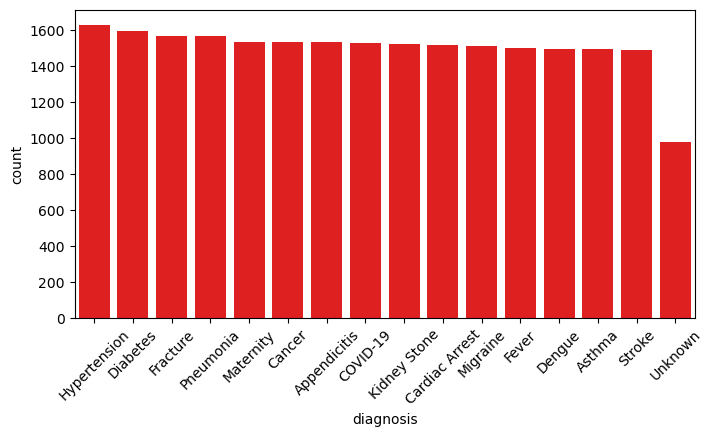

In [314]:
# diagnosis countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="diagnosis", color="red", order=final_df["diagnosis"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Diagnosis-wise Analysis

• Hypertension has the highest number of cases (~1,625).\
• Diabetes is the second most frequent diagnosis (~1,590).\
• Fracture and Pneumonia also have relatively high counts.\
• Most diagnoses have counts between ~1,480–1,600.\
• Unknown has the lowest count (~980).\
• Overall, the diagnosis distribution is relatively balanced.

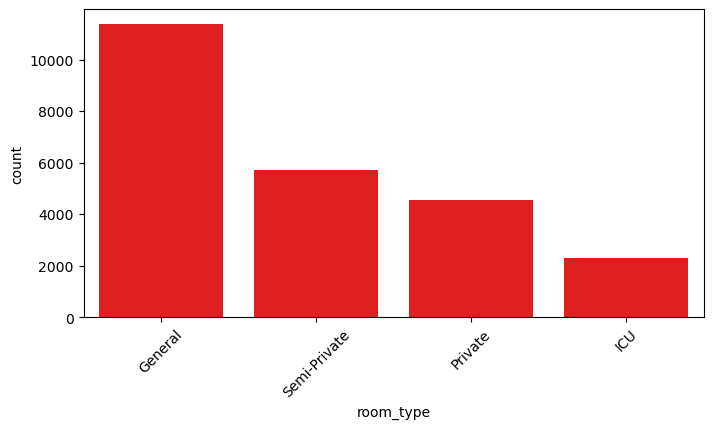

In [315]:
# room type countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="room_type", color="red", order=final_df["room_type"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Room Type Analysis

• General rooms have the highest count (~11,400).\
• Semi-Private rooms are the second most common (~5,700).\
• Private rooms account for ~4,500 records.\
• ICU has the lowest count (~2,300).\
• General rooms have substantially higher representation.\
• Overall, room types are unevenly distributed.

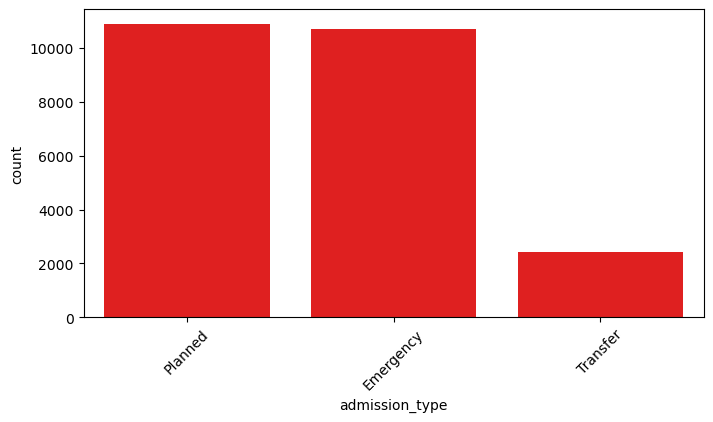

In [316]:
# admission type countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="admission_type", color="red", order=final_df["admission_type"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Admission Type Analysis

• Planned admissions have the highest count (~10,900).\
• Emergency admissions are close behind (~10,700).\
• Transfer admissions have a much lower count (~2,400).\
• Planned and Emergency admissions dominate the dataset.\
• Transfer admissions represent a relatively small proportion.\
• Overall, admission types are unevenly distributed.

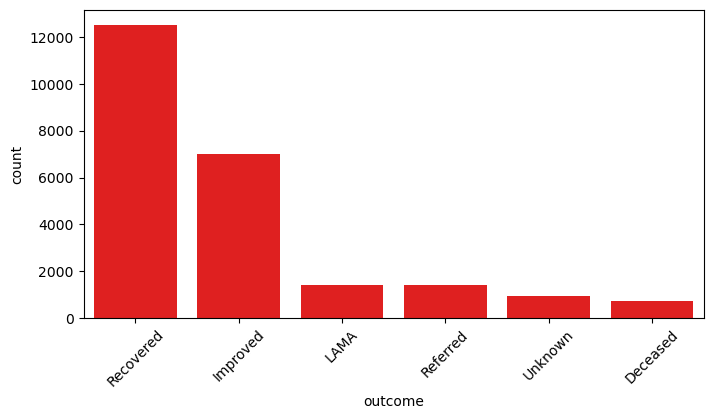

In [317]:
# outcome countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="outcome", color="red", order=final_df["outcome"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Outcome Analysis

• Recovered has the highest count (~12,500).\
• Improved is the second-highest (~7,000).\
• LAMA and Referred have similar counts (~1,400 each).\
• Unknown represents a relatively small number of records (~1,000).\
• Deceased has the lowest count (~700).\
• Most records fall under Recovered and Improved outcomes.

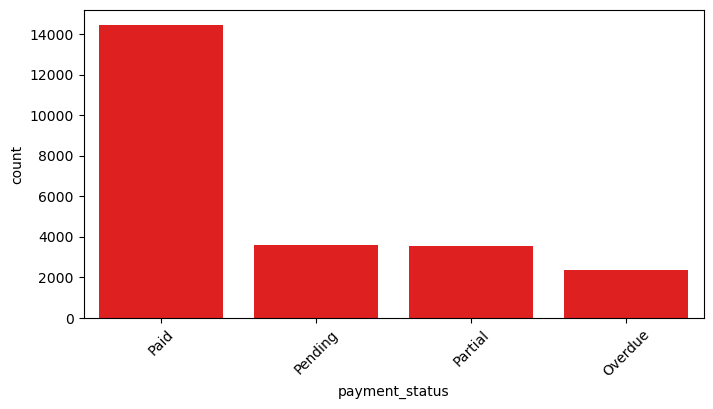

In [318]:
# payment status countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="payment_status", color="red", order=final_df["payment_status"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Payment Status Analysis

• Paid has the highest count (~14,500).\
• Pending and Partial have similar counts (~3,500 each).\
• Overdue has the lowest count (~2,400).\
• Paid records significantly outnumber other payment statuses.\
• Overall, payment statuses are highly unevenly distributed.

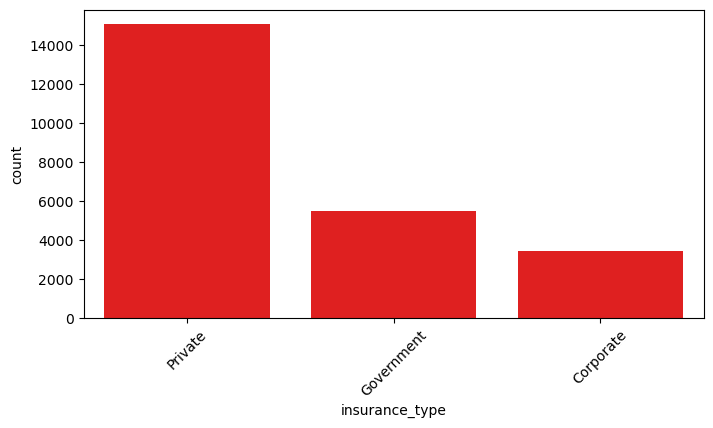

In [319]:
# insurance type countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="insurance_type", color="red", order=final_df["insurance_type"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Insurance Type Analysis

• Private insurance has the highest count (~15,000).\
• Government insurance has ~5,500 records.\
• Corporate insurance has the lowest count (~3,500).\
• Private insurance is substantially more common than other types.\
• Overall, insurance types are unevenly distributed.

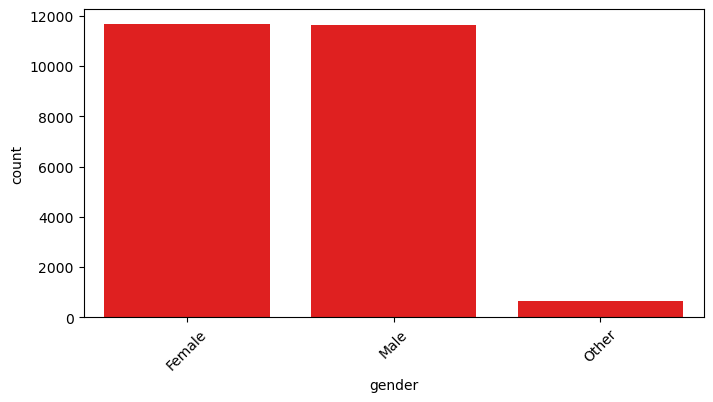

In [320]:
# gender countplot
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x="gender", color="red", order=final_df["gender"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Gender Analysis

• Female: ~11,700 records.\
• Male: ~11,600–11,700 records.\
• Male and Female counts are nearly equal.\
• Other has a much smaller representation (~650).\
• The dataset is largely balanced between Male and Female.

### Bivariate Analysis

#### Numerical vs Numerical

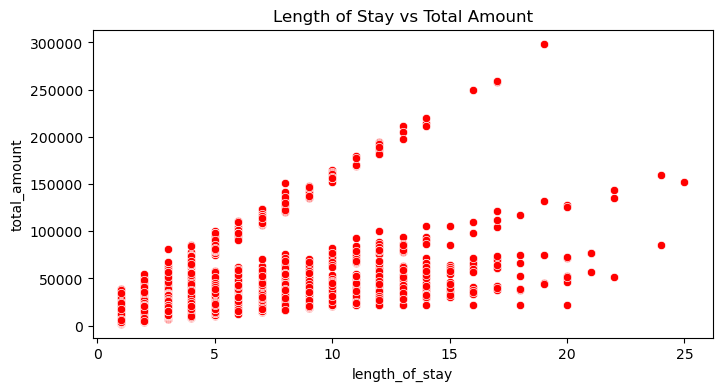

In [321]:
# length of stay vs total amount scatterplot

plt.figure(figsize=(8, 4))
sns.scatterplot(data=final_df.sample(5000, random_state=42), x="length_of_stay", y="total_amount", color="red")
plt.title("Length of Stay vs Total Amount")
plt.show()

# Insights
↓ Length of Stay vs Total Amount

• Total amount generally increases as length of stay increases.\
• Longer stays contain several high-cost cases.\
• Patients with the same stay duration can have very different bills.\
• Some high-value observations reach approximately ₹300,000.\
• The relationship is positive but shows considerable variation.\
• High-cost observations should be investigated further.

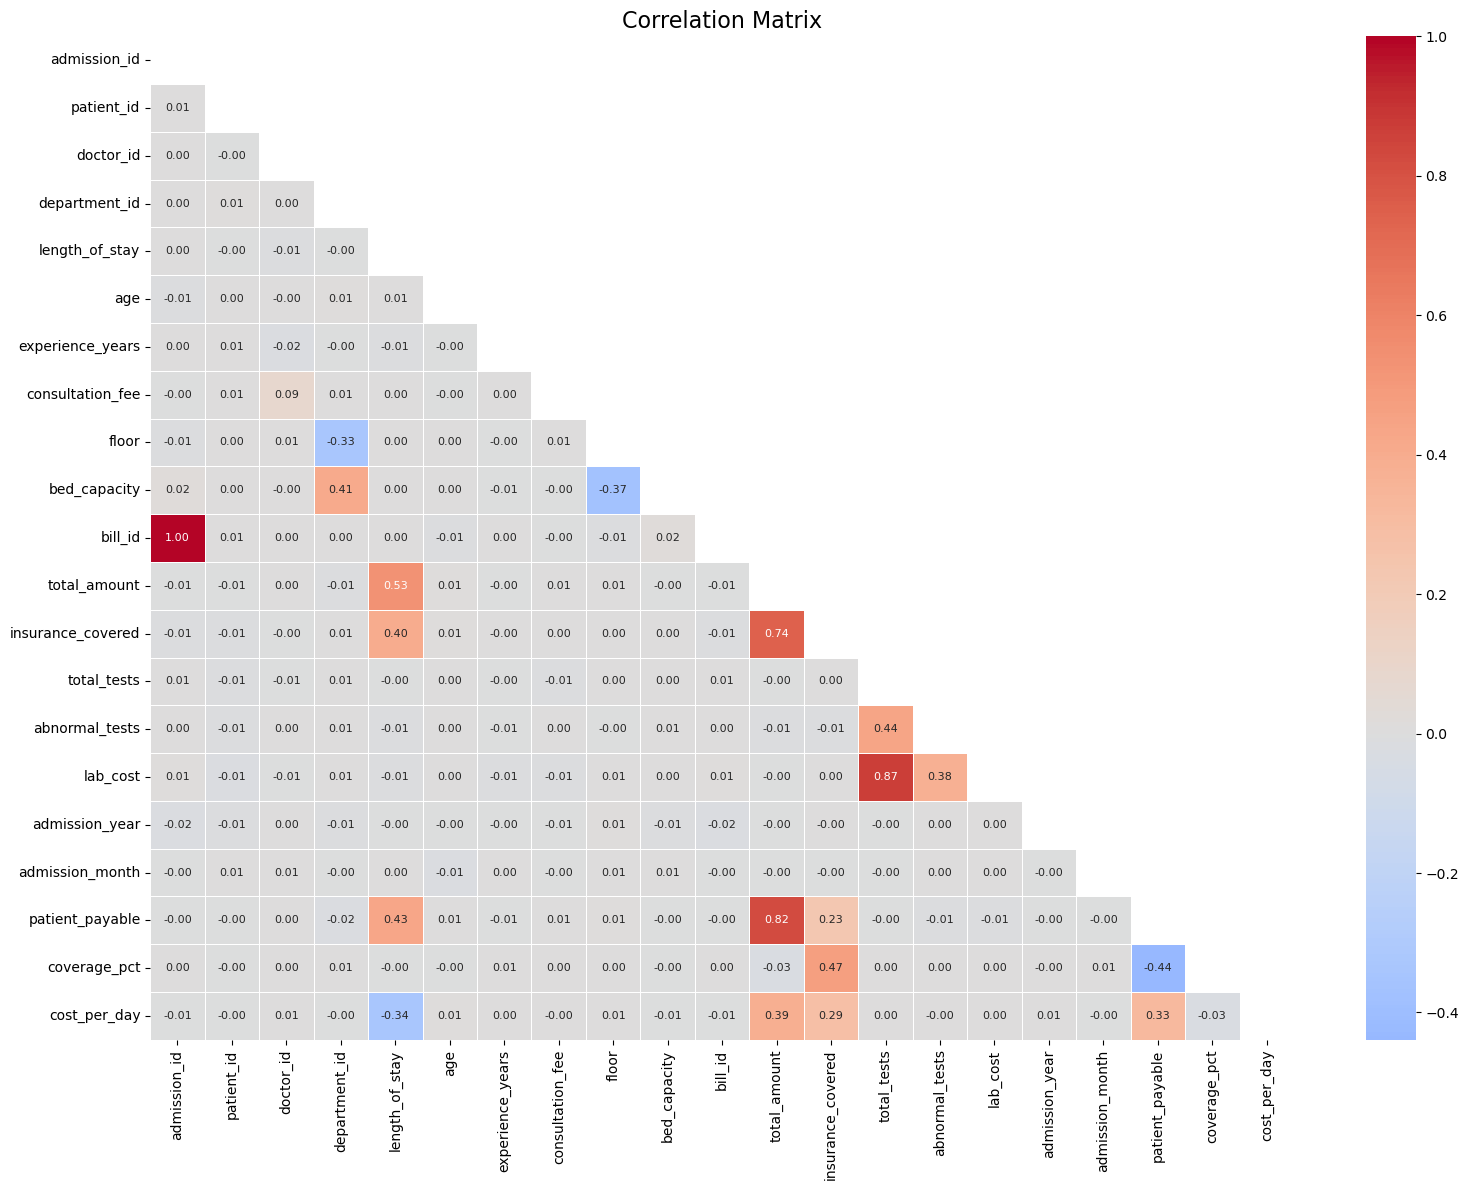

In [322]:
# correlation heatmap

corr = final_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, center=0, annot_kws={"size": 8})
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

### Insight
#### (write your insight here. Note: id columns like patient_id, doctor_id should not be interpreted as business relationships)

#### Categorical vs Numerical

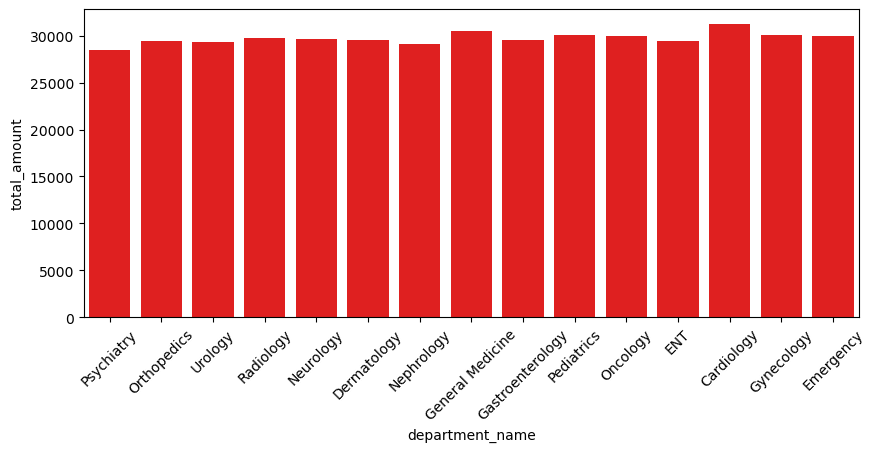

In [323]:
# 1 — Department vs average bill

plt.figure(figsize=(10, 4))
sns.barplot(data=final_df, x="department_name", y="total_amount", color="red", errorbar=None)
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Department-wise Average Total Amount

• Cardiology has the highest average (~₹31,300).\
• General Medicine also has a relatively high average (~₹30,600).\
• Psychiatry has the lowest average (~₹28,500).\
• Most departments fall within a relatively narrow range.\
• Department-level average costs are fairly similar overall.\
• Cardiology could be investigated further for cost drivers.

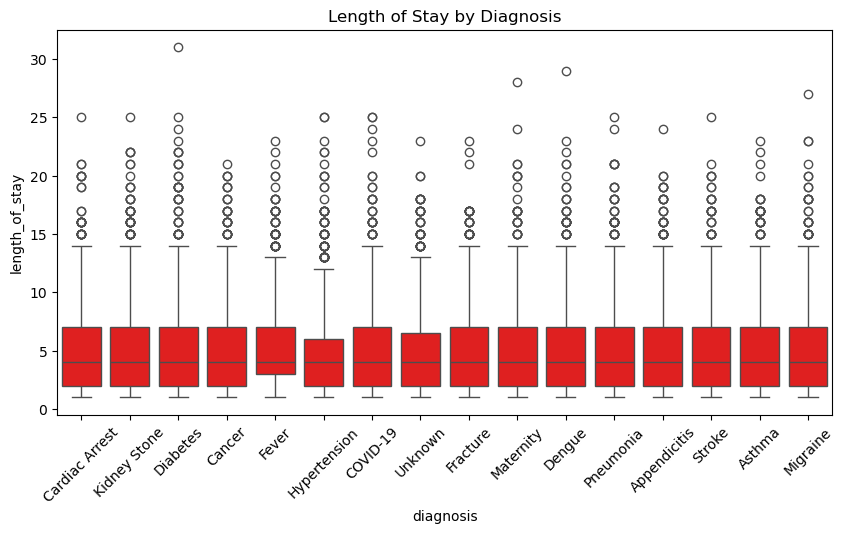

In [324]:
# 2 — Diagnosis vs length of stay

plt.figure(figsize=(10, 5))
sns.boxplot(data=final_df, x="diagnosis", y="length_of_stay", color="red")
plt.title("Length of Stay by Diagnosis")
plt.xticks(rotation=45)
plt.show()

# Insights
↓ Length of Stay by Diagnosis

• Median stay is around 4 days for most diagnoses.\
• The middle 50% generally falls around 2–7 days.\
• Many diagnoses contain high-length-of-stay outliers.\
• Diabetes has the highest visible outlier (~31 days).\
• Dengue (~29 days) and Maternity (~28 days) also show high outliers.\
• Typical length of stay is relatively similar across diagnoses.

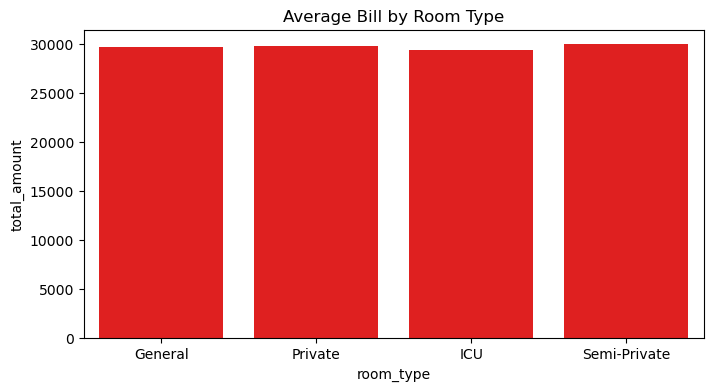

In [325]:
# 3 — Room type vs total amount

plt.figure(figsize=(8, 4))
sns.barplot(data=final_df, x="room_type", y="total_amount", color="red", errorbar=None)
plt.title("Average Bill by Room Type")
plt.show()

## Insights
↓ Average Bill by Room Type

• Semi-Private has the highest average bill (~₹30,000).\
• Private follows closely (~₹29,800).\
• General averages around ₹29,700.\
• ICU has the lowest average (~₹29,400).\
• Average bills are very similar across room types.\
• Room type alone may not strongly influence total bill.

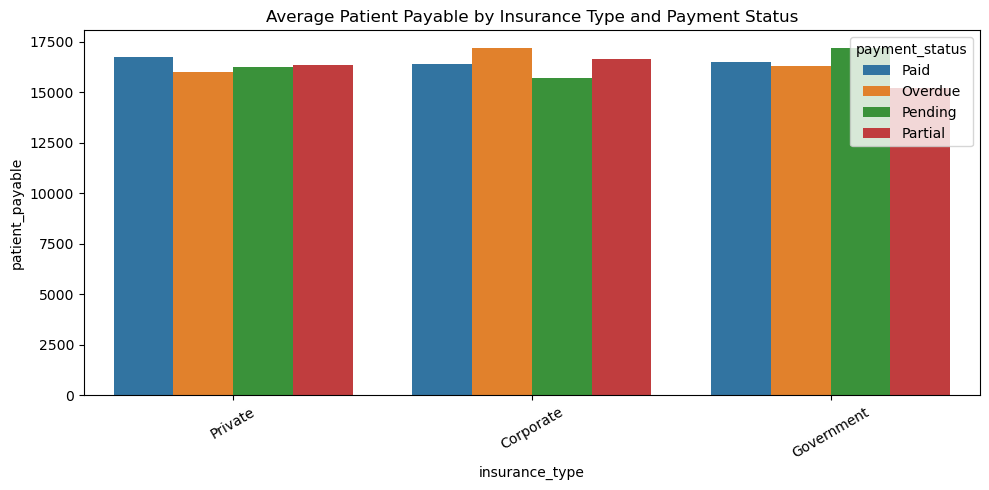

In [326]:
# 4 — Insurance type & payment status vs patient payable

plt.figure(figsize=(10, 5))
sns.barplot(data=final_df, x="insurance_type", y="patient_payable", hue="payment_status", errorbar=None)
plt.title("Average Patient Payable by Insurance Type and Payment Status")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Insights
↓ Insurance Type × Payment Status

• Private–Paid has the highest average payable within Private insurance.\
• Corporate–Overdue has a high average payable (~₹17,200).\
• Government–Pending has a high average payable (~₹17,200).\
• Corporate–Pending and Government–Partial have lower averages (~₹15,700).\
• Payment-status patterns differ across insurance types.\
• Both insurance type and payment status should be considered when analyzing patient payable.

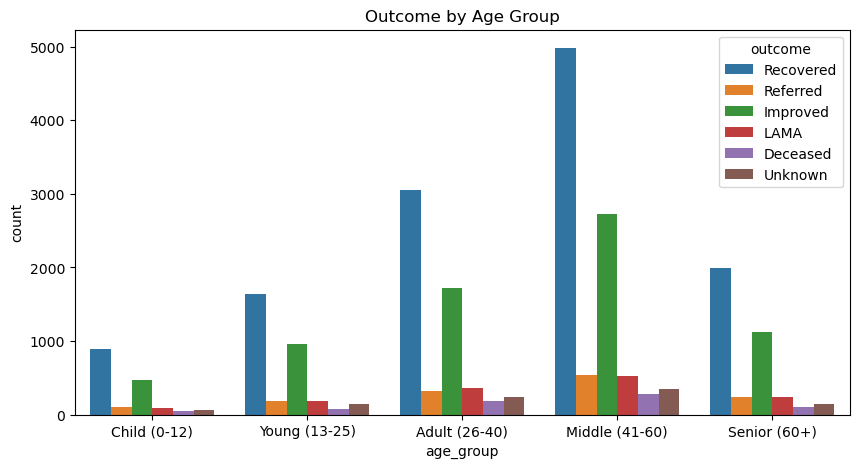

In [327]:
# 5 — Age group vs outcome

plt.figure(figsize=(10, 5))
sns.countplot(data=final_df, x="age_group", hue="outcome")
plt.title("Outcome by Age Group")
plt.show()

## Insights
↓ Outcome by Age Group

• Recovered is the most common outcome across all age groups.\
• Middle-aged patients (41–60) have the highest number of recovered cases (~5,000).\
• Improved is generally the second most common outcome.\
• Child and Young groups have considerably fewer records.\
• Deceased cases are relatively low across all age groups.\
• Middle-aged patients have the highest overall representation.

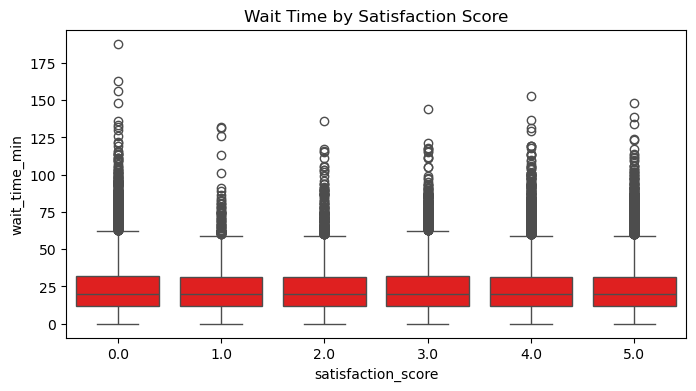

In [328]:
# 6 — Appointment wait time vs satisfaction score

plt.figure(figsize=(8, 4))
sns.boxplot(data=appt_df.dropna(subset=["satisfaction_score"]), x="satisfaction_score", y="wait_time_min", color="red")
plt.title("Wait Time by Satisfaction Score")
plt.show()

## Insights
↓ Wait Time vs Satisfaction Score

• Median wait time is around 20 minutes across most scores.\
• The middle 50% of wait times is relatively similar between groups.\
• All satisfaction groups contain high wait-time outliers.\
• Some outliers exceed 100 minutes.\
• The highest visible wait time is around 185 minutes.\
• No strong relationship between satisfaction score and wait time is apparent.

### Time based analysis

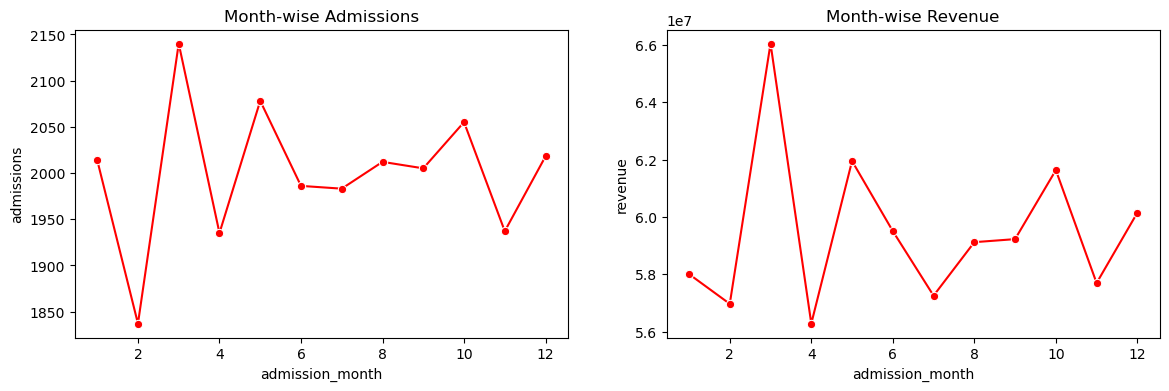

In [329]:
# month wise admissions and revenue

monthly = final_df.groupby("admission_month").agg(admissions=("admission_id", "count"), revenue=("total_amount", "sum")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=monthly, x="admission_month", y="admissions", marker="o", color="red", ax=axes[0]).set_title("Month-wise Admissions")
sns.lineplot(data=monthly, x="admission_month", y="revenue", marker="o", color="red", ax=axes[1]).set_title("Month-wise Revenue")
plt.show()

## Insights
↓ Month-wise Admissions & Revenue

• March has the highest admissions (~2,140) and highest revenue (~₹6.6 Cr).\
• February has the lowest admissions (~1,835).\
• April has the lowest revenue (~₹5.6 Cr).\
• October is another strong month for both admissions and revenue.\
• Admissions fluctuate between ~1,850–2,140 per month.\
• Revenue does not always move proportionally with admissions.\
• Other factors besides patient volume may influence hospital revenue.

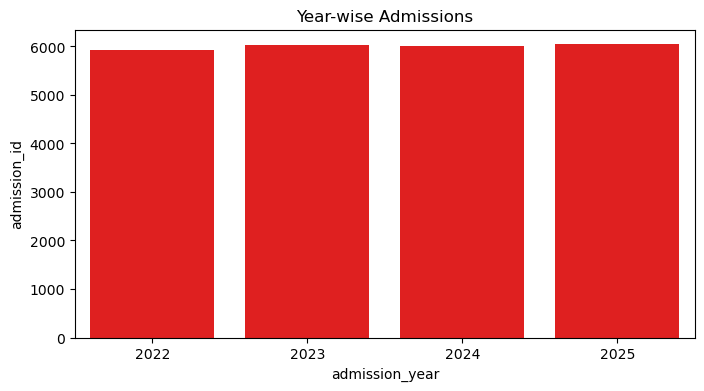

In [330]:
# year wise admissions

yearly = final_df.groupby("admission_year")["admission_id"].count().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=yearly, x="admission_year", y="admission_id", color="red")
plt.title("Year-wise Admissions")
plt.show()

## Insights
↓ Year-wise Admission Analysis

• Admissions remain close to ~6,000 every year.\
• 2022 has the lowest admissions (~5,900).\
• Admissions increase slightly in 2023.\
• 2024 remains relatively stable.\
• 2025 has the highest admissions (~6,050–6,100).\
• Overall, admissions show a stable trend from 2022–2025.

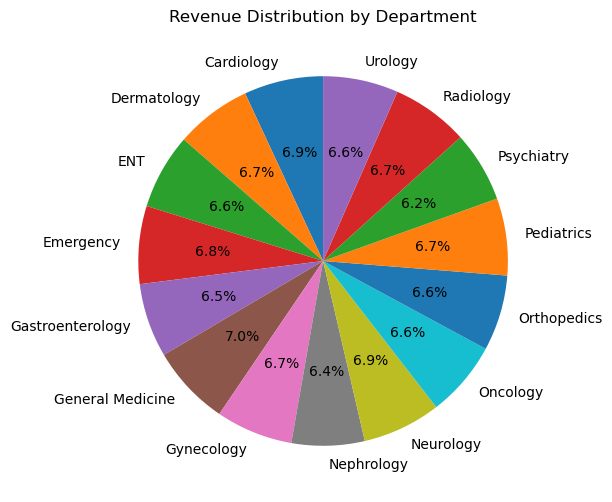

In [331]:
# departmentwise total revenue

dept_revenue = final_df.groupby("department_name")["total_amount"].sum()

plt.figure(figsize=(6, 6))
plt.pie(dept_revenue, labels=dept_revenue.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Distribution by Department")
plt.show()

## Insights
↓ Revenue Distribution by Department

• General Medicine has the highest revenue share (~7.0%).\
• Cardiology contributes ~6.9%.\
• Emergency contributes ~6.8%.\
• Nephrology has the lowest share (~6.4%).\
• Most departments contribute between ~6.2%–7.0%.\
• Revenue is relatively evenly distributed across departments.

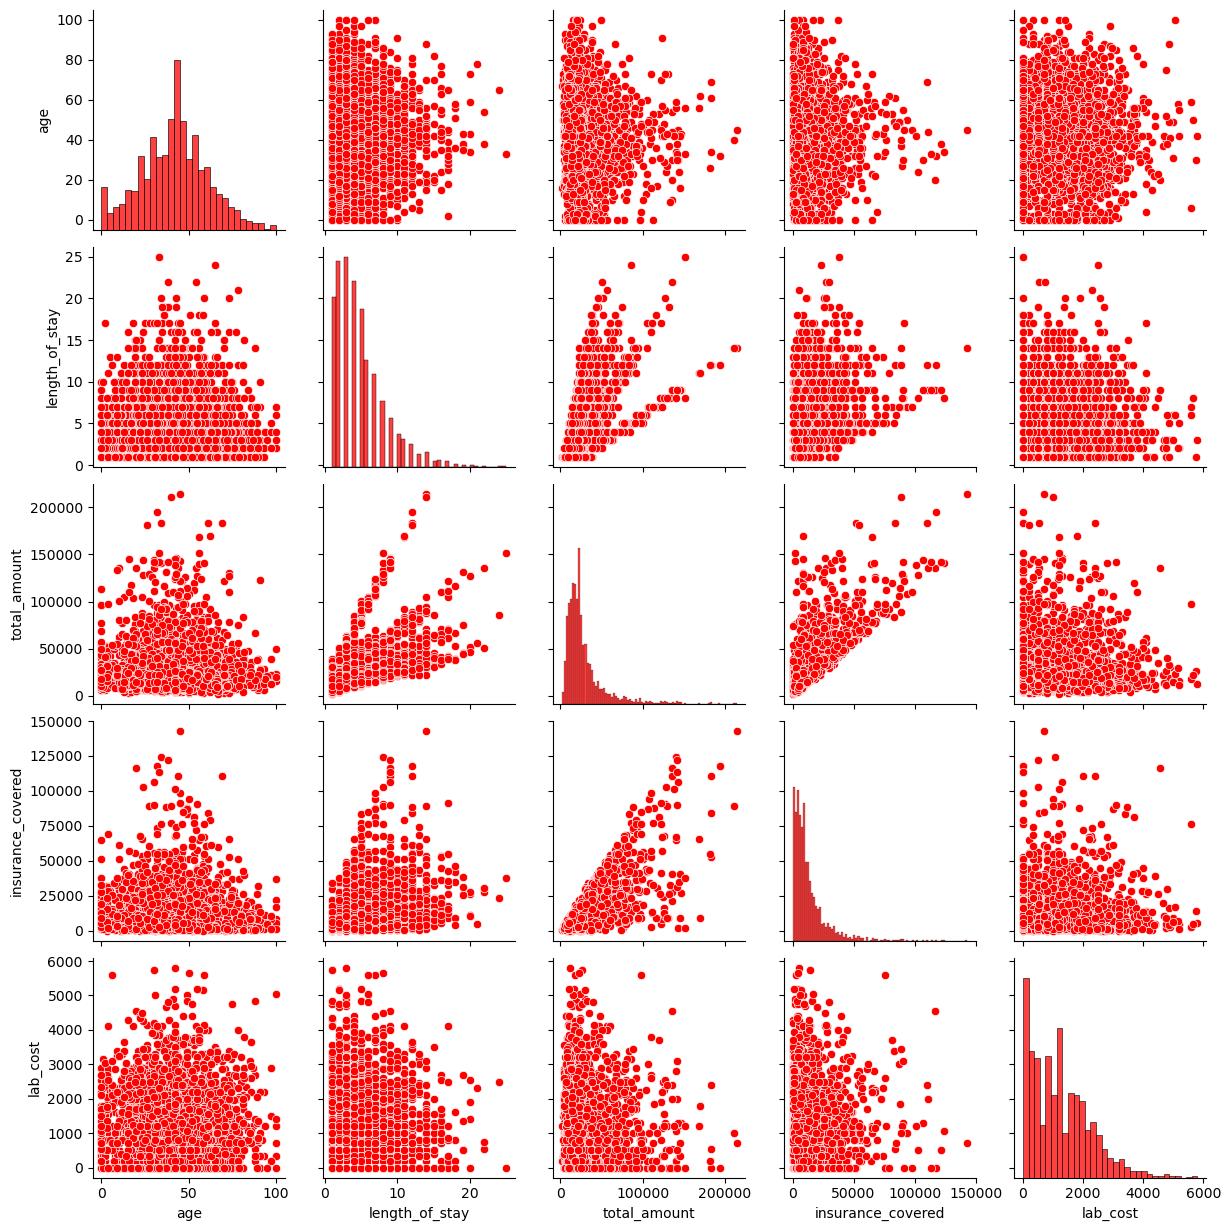

In [332]:
cols = ["age", "length_of_stay", "total_amount", "insurance_covered", "lab_cost"]

sns.pairplot(
    final_df[cols].sample(3000, random_state=42),
    diag_kind="hist",
    plot_kws={"color": "red"},
    diag_kws={"color": "red"}
)
plt.show()

## Insights
↓ Pairplot Analysis

• Length of stay and total amount show a positive relationship.\
• Higher lab costs are generally associated with higher total bills.\
• Insurance-covered amount tends to increase with total amount.\
• Age shows a weaker direct relationship with billing variables.\
• Diagonal distributions help identify skewness and outliers.

# Business Questions

### 1 . Using final_df, perform a department-wise analysis.
Calculate for each department:
Total Admissions ,
Total Revenue,
Average Length of Stay

Sort by total revenue in descending order

In [333]:
final_df.groupby("department_name").agg(
    total_admissions=("admission_id", "count"),
    total_revenue=("total_amount", "sum"),
    avg_length_of_stay=("length_of_stay", "mean")
).sort_values("total_revenue", ascending=False)

,total_admissions,total_revenue,avg_length_of_stay
department_name,,,
General Medicine,1647,5.017383e+07,5.076012
Cardiology,1581,4.947435e+07,5.101629
Neurology,1653,4.897495e+07,5.027245
Emergency,1624,4.862606e+07,5.003766
Radiology,1618,4.813471e+07,5.064353
Pediatrics,1598,4.812204e+07,4.991026
Gynecology,1598,4.806372e+07,4.998722
Dermatology,1610,4.752420e+07,4.967370
Oncology,1581,4.733015e+07,5.002602


#### 2 . Find the top 5 diagnoses by average bill amount.

In [334]:
final_df.groupby("diagnosis")["total_amount"].mean().sort_values(ascending=False).head(5)

diagnosis
Cardiac Arrest    30911.802383
Unknown           30591.251489
Kidney Stone      30492.717528
Fracture          30083.223166
Stroke            29901.967116
Name: total_amount, dtype: float64

#### 3 . Using final_df, find the top 3 doctors in each department based on number of admissions handled.

In [335]:
top_3_doctors = (
    final_df
    .groupby(["department_name", "doctor_name"])
    .size()
    .reset_index(name="admission_count")
)

top_3_doctors["rank"] = (
    top_3_doctors
    .groupby("department_name")["admission_count"]
    .rank(method="dense", ascending=False)
)

top_3_doctors = (
    top_3_doctors[top_3_doctors["rank"] <= 3]
    .sort_values(["department_name", "rank"])
)

top_3_doctors

,department_name,doctor_name,admission_count,rank
149,Cardiology,Dr. Sneha Bose,34,1.0
130,Cardiology,Dr. Ritu Singh,29,2.0
15,Cardiology,Dr. Arjun Gupta,28,3.0
280,Dermatology,Dr. Priya Malhotra,36,1.0
212,Dermatology,Dr. Isha Gupta,28,2.0
...,...,...,...,...
2490,Urology,Dr. Meera Joshi,25,2.0
2531,Urology,Dr. Rahul Bose,25,2.0
2547,Urology,Dr. Ritu Singh,25,2.0
2432,Urology,Dr. Arjun Gupta,24,3.0


#### 4 . Calculate the outstanding amount (payment_status = Pending / Overdue / Partial) for each department. Keep only departments where the outstanding amount is above the overall average.

In [336]:
# 1. Filter outstanding payments
outstanding_df = final_df[
    final_df["payment_status"].isin(["Pending", "Overdue", "Partial"])
]

# 2. Calculate outstanding amount by department
dept_outstanding = (
    outstanding_df
    .groupby("department_name")["patient_payable"]
    .sum()
    .reset_index(name="outstanding_amount")
)

# 3. Calculate overall average outstanding amount
overall_avg = dept_outstanding["outstanding_amount"].mean()

# 4. Keep departments above overall average
result = dept_outstanding[
    dept_outstanding["outstanding_amount"] > overall_avg
].sort_values("outstanding_amount", ascending=False)

result = result.reset_index(drop=True)
result["outstanding_amount"] = result["outstanding_amount"].round(2)

result

,department_name,outstanding_amount
0,General Medicine,11130668.87
1,Oncology,10916341.76
2,Gynecology,10893479.00
3,Urology,10855558.00
4,Neurology,10696991.30
5,Cardiology,10624237.53
6,Orthopedics,10475628.87
7,Pediatrics,10341448.46


#### 5 . Using appt_df, calculate the no-show rate and cancellation rate for each appointment_type.

In [337]:
appointment_rates = (
    appt_df
    .groupby("appointment_type")
    .agg(
        total_appointments=("status", "size"),
        no_shows=("status", lambda x: (x == "No-Show").sum()),
        cancellations=("status", lambda x: (x == "Cancelled").sum())
    )
    .reset_index()
)

appointment_rates["no_show_rate"] = (
    appointment_rates["no_shows"] /
    appointment_rates["total_appointments"] * 100
)

appointment_rates["cancellation_rate"] = (
    appointment_rates["cancellations"] /
    appointment_rates["total_appointments"] * 100
)

appointment_rates["no_show_rate"] = appointment_rates["no_show_rate"].round(2)
appointment_rates["cancellation_rate"] = appointment_rates["cancellation_rate"].round(2)

appointment_rates

,appointment_type,total_appointments,no_shows,cancellations,no_show_rate,cancellation_rate
0,Consultation,24378,2429,2947,9.96,12.09
1,Emergency,5536,533,661,9.63,11.94
2,Follow-up,13796,1357,1648,9.84,11.95
3,Routine Checkup,8326,854,1000,10.26,12.01
4,Teleconsultation,5400,539,600,9.98,11.11


Appointment type does not show a large difference in no-show or cancellation rates.\
Rates remain relatively consistent across all appointment types, \
although Routine Checkups have the highest no-show rate and Consultations have the highest cancellation rate.

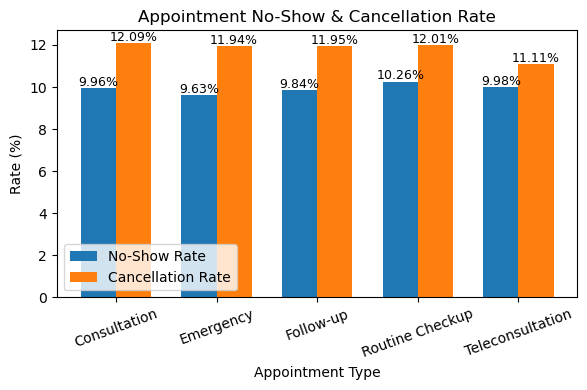

In [347]:

# Data
appointment_types = appointment_rates["appointment_type"]
no_show = appointment_rates["no_show_rate"]
cancellation = appointment_rates["cancellation_rate"]

# X positions
x = np.arange(len(appointment_types))
width = 0.35

# Create figure
plt.figure(figsize=(6, 4))

# Bars
plt.bar(
    x - width/2,
    no_show,
    width,
    label="No-Show Rate"
)

plt.bar(
    x + width/2,
    cancellation,
    width,
    label="Cancellation Rate"
)

# Labels
plt.title("Appointment No-Show & Cancellation Rate")
plt.xlabel("Appointment Type")
plt.ylabel("Rate (%)")

plt.xticks(x, appointment_types, rotation=20)

# Add values above bars
for i, value in enumerate(no_show):
    plt.text(
        i - width/2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

for i, value in enumerate(cancellation):
    plt.text(
        i + width/2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.legend()

plt.tight_layout()


plt.show()

#### 6 . Using appt_df, find the average wait time and average satisfaction score for each department. Which department has the longest wait?

In [338]:
dept_wait_satisfaction = (
    appt_df
    .groupby("department_name")
    .agg(
        avg_wait_time=("wait_time_min", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean")
    )
    .reset_index()
)

dept_wait_satisfaction["avg_wait_time"] = (
    dept_wait_satisfaction["avg_wait_time"].round(2)
)

dept_wait_satisfaction["avg_satisfaction_score"] = (
    dept_wait_satisfaction["avg_satisfaction_score"].round(2)
)

dept_wait_satisfaction

,department_name,avg_wait_time,avg_satisfaction_score
0,Cardiology,23.79,2.65
1,Dermatology,23.47,2.66
2,ENT,23.49,2.65
3,Emergency,23.48,2.63
4,Gastroenterology,23.14,2.63
5,General Medicine,23.30,2.59
6,Gynecology,23.63,2.65
7,Nephrology,24.11,2.60
8,Neurology,23.93,2.57
9,Oncology,23.85,2.62


In [339]:
longest_wait_dept = dept_wait_satisfaction.loc[
    dept_wait_satisfaction["avg_wait_time"].idxmax()
]

longest_wait_dept

department_name           Radiology
avg_wait_time                 24.35
avg_satisfaction_score         2.68
Name: 13, dtype: object

Radiology has the longest average waiting time at 24.35 minutes, while Gastroenterology has the shortest at 23.14 minutes. \
Overall, waiting times are fairly similar across departments. Radiology also records the highest average satisfaction score of 2.68.

#### 7 . Calculate the mortality rate (outcome = Deceased) for each diagnosis. Keep only diagnoses with at least 100 admissions.

In [340]:
mortality_by_diagnosis = (
    final_df
    .groupby("diagnosis")
    .agg(
        total_admissions=("outcome", "size"),
        deceased=("outcome", lambda x: (x == "Deceased").sum())
    )
    .reset_index()
)

# Keep only diagnoses with at least 100 admissions
mortality_by_diagnosis = mortality_by_diagnosis[
    mortality_by_diagnosis["total_admissions"] >= 100
]

# Calculate mortality rate
mortality_by_diagnosis["mortality_rate"] = (
    mortality_by_diagnosis["deceased"] /
    mortality_by_diagnosis["total_admissions"] * 100
)

# Sort by mortality rate
mortality_by_diagnosis = mortality_by_diagnosis.sort_values(
    "mortality_rate",
    ascending=False
)

mortality_by_diagnosis

,diagnosis,total_admissions,deceased,mortality_rate
15,Unknown,977,36,3.684749
10,Kidney Stone,1523,55,3.611293
1,Asthma,1495,52,3.478261
5,Dengue,1495,51,3.411371
11,Maternity,1535,52,3.387622
14,Stroke,1491,48,3.219316
13,Pneumonia,1565,49,3.130990
7,Fever,1498,46,3.070761
3,Cancer,1534,47,3.063885
2,COVID-19,1530,46,3.006536


#### 8 . Compare the average length of stay and average bill for Emergency vs Planned admissions.

In [341]:
admission_comparison = (
    final_df[
        final_df["admission_type"].isin(["Emergency", "Planned"])
    ]
    .groupby("admission_type")
    .agg(
        avg_length_of_stay=("length_of_stay", "mean"),
        avg_bill=("total_amount", "mean")
    )
    .reset_index()
)

# Round values
admission_comparison["avg_length_of_stay"] = (
    admission_comparison["avg_length_of_stay"].round(2)
)

admission_comparison["avg_bill"] = (
    admission_comparison["avg_bill"].round(2)
)

admission_comparison

,admission_type,avg_length_of_stay,avg_bill
0,Emergency,5.01,30029.90
1,Planned,5.00,29543.14


#### 9 . For each insurance_type, calculate average coverage_pct and average patient_payable.

In [342]:
insurance_summary = (
    final_df
    .groupby("insurance_type")
    .agg(
        avg_coverage_pct=("coverage_pct", "mean"),
        avg_patient_payable=("patient_payable", "mean")
    )
    .reset_index()
)

# Round the results
insurance_summary["avg_coverage_pct"] = (
    insurance_summary["avg_coverage_pct"].round(2)
)

insurance_summary["avg_patient_payable"] = (
    insurance_summary["avg_patient_payable"].round(2)
)

insurance_summary

,insurance_type,avg_coverage_pct,avg_patient_payable
0,Corporate,45.72,16424.80
1,Government,45.03,16374.69
2,Private,45.22,16528.46


#### 10 . Which lab test has the highest abnormal rate? (use df_lab)

In [343]:
abnormal_rate = (
    df_lab
    .groupby("test_name")
    .agg(
        total_tests=("result_flag", "size"),
        abnormal_tests=("result_flag", lambda x: (x == "Abnormal").sum())
    )
    .reset_index()
)

abnormal_rate["abnormal_rate"] = (
    abnormal_rate["abnormal_tests"] /
    abnormal_rate["total_tests"] * 100
)

abnormal_rate = abnormal_rate.sort_values(
    "abnormal_rate",
    ascending=False
)

abnormal_rate

,test_name,total_tests,abnormal_tests,abnormal_rate
0,Blood Sugar,8386,1698,20.248032
2,Creatinine,8346,1679,20.117422
1,Cholesterol,8375,1668,19.916418
3,Hemoglobin,8175,1589,19.437309
4,Platelets,8398,1625,19.349845
5,WBC Count,8320,1597,19.194712


Blood Sugar has the highest abnormal rate at 20.25%, followed by Creatinine at 20.12%. \
WBC Count has the lowest abnormal rate at 19.19%. Overall, the abnormal rates are fairly\
close across all lab tests, ranging from approximately 19.19% to 20.25%.

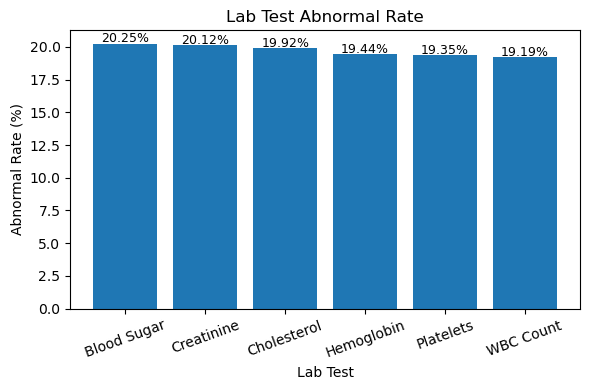

In [349]:
# Data
test_names = abnormal_rate["test_name"]
rates = abnormal_rate["abnormal_rate"]

# Create figure
plt.figure(figsize=(6, 4))

# Bar chart
bars = plt.bar(test_names, rates)

# Title and labels
plt.title("Lab Test Abnormal Rate")
plt.xlabel("Lab Test")
plt.ylabel("Abnormal Rate (%)")

# Rotate labels
plt.xticks(rotation=20)

# Add percentage values above bars
for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{rate:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()



plt.show()

<h2 align="center">EXECUTIVE SUMMARY</h2>

#### This project focuses on performing an end-to-end Hospital Analytics and Exploratory Data Analysis (EDA) using multiple interconnected datasets such as Departments, Doctors, Patients, Appointments, Admissions, Billing, and Lab Tests.

#### The project involved understanding the raw data, identifying data-quality issues, cleaning and standardizing each table, checking foreign-key relationships, combining tables using appropriate keys, and creating features such as Length of Stay, Patient Payable, Coverage %, Cost per Day and Age Group.

#### The analysis identified clear differences in hospital utilization, billing, payment patterns,
#### and patient outcomes across departments, admission types, and insurance categories.
#### Lab-test analysis showed that Blood Sugar had the highest abnormal rate at 20.25%, while appointment analysis showed relatively 
#### similar no-show and cancellation rates across appointment types.
#### Overall, the analysis provided actionable insights into hospital operations, patient behavior, financial performance,
#### and healthcare service patterns.

<h2 align="center">KEY BUSINESS INSIGHT</h2>

### 1. Department Performance
#### General Medicine and Cardiology contribute strongly to overall hospital revenue, while department-wise average billing remains relatively similar. This indicates that revenue is distributed fairly evenly across departments rather than being concentrated in one department.

### 2. Billing & Insurance
#### Private insurance accounts for the largest share of patients. Outstanding payments are concentrated in departments such as General Medicine, Oncology, and Gynecology, highlighting areas where payment collection may require greater attention.

### 3. Patient Care (length of stay, outcome)
#### Most patients have relatively similar lengths of stay across diagnoses, although some diagnoses show high-length-of-stay outliers. Recovered patients represent the largest outcome category across age groups, followed by Improved patients.

### 4. Appointments (wait time, no-show, satisfaction)
#### Average waiting times are fairly similar across departments, with Radiology having the longest average wait at 24.35 minutes. No-show and cancellation rates are also relatively consistent across appointment types, while satisfaction scores show only modest differences.

### 5. Data Quality
#### The project identified several real-world data-quality problems, including:
#### Missing values
#### Duplicate records
#### Mixed date formats
#### Inconsistent categorical values and spelling mistakes
#### Impossible values (negative age, discharge before admission, placeholder -999)
#### Orphan records (broken foreign keys)

<h2 align="center">FINAL CONCLUSION</h2>

#### The Hospital Analytics project demonstrates the complete workflow of converting raw, imperfect hospital data into meaningful business insights.

#### Overall, this project demonstrates practical skills in:
#### Python → Pandas → NumPy → Data Cleaning → Data Integration → Feature Engineering → EDA → Visualization → Business Insights

## Final Quality Note

#### The cleaned analytical dataset is used for the final business analysis.
#### Categorical values were standardized, invalid business-rule values were handled,
#### and derived metrics such as length of stay, patient payable, coverage % and cost per day were used to support the analysis.

#### > Note: Statistical outliers are not automatically treated as invalid records;
#### > business context should be considered before excluding extreme observations.